In [ ]:
# ETL
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Análise dos dados
import matplotlib
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelagem Preditiva
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

%matplotlib inline

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Métricas de Avaliação de Modelos
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_amazon_sales = pd.read_csv('/content/drive/MyDrive/Dataset ciência de dados/amazon.csv')

In [ ]:
df_amazon_sales.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
df_amazon_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

# Tratamento dos Dados

In [ ]:
df_amazon_sales.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [ ]:
df_amazon_sales[df_amazon_sales.isna().any(axis=1)]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
282,B0B94JPY2N,Amazon Brand - Solimo 65W Fast Charging Braide...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,80%,3.0,NaN,USB C to C Cable: This cable has type C connec...,AE7CFHY23VAJT2FI4NZKKP6GS2UQ,Pranav,RUB7U91HVZ30,The cable works but is not 65W as advertised,I have a pd supported car charger and I bought...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Amazon-Brand-Charging-Su...
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,₹249,₹999,75%,5.0,NaN,💎[The Fastest Charge] - This iPhone USB C cabl...,AGJC5O5H5BBXWUV7WRIEIOOR3TVQ,Abdul Gafur,RQXD5SAMMPC6L,Awesome Product,Quick delivery.Awesome ProductPacking was good...,https://m.media-amazon.com/images/I/31-q0xhaTA...,https://www.amazon.in/REDTECH-Lightning-Certif...


In [ ]:
df_amazon_sales['rating_count'] = df_amazon_sales['rating_count'].astype('string')

In [ ]:
df_amazon_sales['rating_count'] = df_amazon_sales['rating_count'].str.replace(',', '')

In [ ]:
df_amazon_sales = df_amazon_sales.dropna(subset=['rating_count'])

In [ ]:
df_amazon_sales.isna().sum()

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,0
about_product,0
user_id,0


In [ ]:
df_amazon_sales[df_amazon_sales.isna().any(axis=1)]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link


In [ ]:
df_amazon_sales['rating_count'] = df_amazon_sales['rating_count'].astype('int64')

In [ ]:
df_amazon_sales[['product_id', 'product_name']] = df_amazon_sales[['product_id', 'product_name']].astype('string')

In [ ]:
df_amazon_sales = df_amazon_sales.drop(columns=['img_link', 'product_link'])

In [ ]:
df_amazon_sales[['discounted_price', 'actual_price']] = df_amazon_sales[['discounted_price', 'actual_price']].astype('string')

In [ ]:
df_amazon_sales[['discounted_price', 'actual_price']] = (
    df_amazon_sales[['discounted_price', 'actual_price']]
    .apply(lambda col: col.astype('string')
           .str.replace(',', '', regex=False)
           .str.replace('₹', '', regex=False))
)

In [ ]:
df_amazon_sales[['discounted_price', 'actual_price']] = df_amazon_sales[['discounted_price', 'actual_price']].astype('float64')
df_amazon_sales[['discounted_price', 'actual_price']] *= 0.057 # Conversão de rúpias para reais (aproximado)
df_amazon_sales[['discounted_price', 'actual_price']] = df_amazon_sales[['discounted_price', 'actual_price']].round(2)

In [ ]:
df_amazon_sales.loc[
    pd.to_numeric(df_amazon_sales['rating'], errors='coerce').isna(),
    'rating'
].value_counts(dropna=False)

,count
rating,
|,1


In [ ]:
df_amazon_sales['rating'] = (
    df_amazon_sales['rating']
    .astype('string')
    .str.replace('|', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

In [ ]:
df_amazon_sales['category'] = df_amazon_sales['category'].astype('string')

In [ ]:
df_amazon_sales['category'] = df_amazon_sales['category'].apply(lambda x: x.split('|'))

In [ ]:
df_amazon_sales['discount_percentage'] = df_amazon_sales['discount_percentage'].astype('string')
df_amazon_sales['discount_percentage'] = df_amazon_sales['discount_percentage'].str.replace('%', '', regex=False)
df_amazon_sales['discount_percentage'] = df_amazon_sales['discount_percentage'].astype('int64')

In [ ]:
df_amazon_sales['about_product'] = df_amazon_sales['about_product'].astype('string')

In [ ]:
df_amazon_sales['user_id'] = df_amazon_sales['user_id'].str.split(',')
df_amazon_sales['user_name'] = df_amazon_sales['user_name'].str.split(',')
df_amazon_sales['review_id'] = df_amazon_sales['review_id'].str.split(',')
df_amazon_sales['review_title'] = df_amazon_sales['review_title'].str.split(',')
df_amazon_sales['review_content'] = df_amazon_sales['review_content'].str.split(',')
df_amazon_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1463 entries, 0 to 1464
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1463 non-null   string 
 1   product_name         1463 non-null   string 
 2   category             1463 non-null   object 
 3   discounted_price     1463 non-null   float64
 4   actual_price         1463 non-null   float64
 5   discount_percentage  1463 non-null   int64  
 6   rating               1462 non-null   Float64
 7   rating_count         1463 non-null   int64  
 8   about_product        1463 non-null   string 
 9   user_id              1463 non-null   object 
 10  user_name            1463 non-null   object 
 11  review_id            1463 non-null   object 
 12  review_title         1463 non-null   object 
 13  review_content       1463 non-null   object 
dtypes: Float64(1), float64(2), int64(2), object(6), string(3)
memory usage: 172.9+ KB


In [ ]:
df_amazon_sales[df_amazon_sales.duplicated(subset=['product_id'])]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
369,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,"[Computers&Accessories, Accessories&Peripheral...",22.74,62.64,64,4.2,24270,High Compatibility : Compatible With iPhone 12...,"[AG3D6O4STAQKAY2UVGEUV46KN35Q, AHMY5CWJMMK5BJR...","[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...","[R3HXWT0LRP0NMF, R2AJM3LFTLZHFO, R6AQJGUP6P86,...","[Satisfied, Charging is really fast, Value for...",[Looks durable Charging is fine tooNo complain...
377,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"[Computers&Accessories, Accessories&Peripheral...",11.34,19.89,43,4.0,43993,"Compatible with all Type C enabled devices, be...","[AECPFYFQVRUWC3KGNLJIOREFP5LQ, AGYYVPDD7YG7FYN...","[ArdKn, Nirbhay kumar, Sagar Viswanathan, Asp,...","[RGIQEG07R9HS2, R1SMWZQ86XIN8U, R2J3Y1WL29GWDE...","[A Good Braided Cable for Your Type C Device, ...",[I ordered this cable to connect my phone to A...
379,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,"[Computers&Accessories, Accessories&Peripheral...",11.34,56.94,80,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"[AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA, AESFLDV2PT363T2...","[Kunal, Himanshu, viswanath, sai niharka, saqi...","[R3J3EQQ9TZI5ZJ, R3E7WBGK7ID0KV, RWU79XKQ6I1QF...","[Good speed for earlier versions, Good Product...","[Not quite durable and sturdy, https://m.media..."
392,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,"[Computers&Accessories, Accessories&Peripheral...",18.75,39.84,53,4.2,94364,The boAt Deuce USB 300 2 in 1 cable is compati...,"[AEWAZDZZJLQUYVOVGBEUKSLXHQ5A, AG5HTSFRRE6NL3M...","[Omkar dhale, JD, HEMALATHA, Ajwadh a., amar s...","[R3EEUZKKK9J36I, R3HJVYCLYOY554, REDECAZ7AMPQC...","[Good product, Good one, Nice, Really nice pro...","[Good product, long wire, Charges good, Nice, ..."
393,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,"[Computers&Accessories, Accessories&Peripheral...",8.78,22.74,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"[AE3Q6KSUK5P75D5HFYHCRAOLODSA, AFUGIFH5ZAFXRDS...","[rahuls6099, Swasat Borah, Ajay Wadke, Pranali...","[R1BP4L2HH9TFUP, R16PVJEXKV6QZS, R2UPDB81N66T4...","[As good as original, Decent, Good one for sec...","[Bought this instead of original apple, does ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1007,B0B9BXKBC7,"WeCool S5 Long Selfie Stick, with Large Reinfo...","[Electronics, Mobiles&Accessories, MobileAcces...",102.54,227.94,55,4.6,245,"64"" Tall Cell Phone Tripods with 7 section adj...","[AFPYH3UF3GB4RNX3MX46AXFM2FTQ, AGWEQHJSUA4YCG4...","[Sujili v, Paras Jain, Shailendra, supreeth ac...","[R2MI4KSWYUEMDR, R2MNYKDL2UII1M, R2C6TUBM6IVLB...","[Good, Good Product but Little expensive., Hap...","[Good, Thoda sa kam stable hai, phone lagane ..."
1010,B07GVGTSLN,Wayona Usb Type C Fast Charger Cable Fast Char...,"[Computers&Accessories, Accessories&Peripheral...",18.53,74.04,75,4.2,10576,Fast Charge & Data Sync: Fast charge& data tra...,"[AEXK37TSBFHSP2TYE63YPKETWQ7Q, AEKMVX2VDNNX4ZF...","[Sunil Funde, Biju Abraham Thomas, Samir, Rahu...","[R10365HEDURWI9, R5RP542IMC4OI, RX2HFWXTTQDTS,...","[Nice product ., Good quality Braided cable, ...","[Sturdy packing, good product!, Have used thi..."
1017,B0B9BD2YL4,KINGONE Wireless Charging Pencil (2nd Generati...,"[Electronics, Mobiles&Accessories, MobileAcces...",148.14,398.94,63,4.5,1526,【2022 latest iPad Magnetic Charging】 The lates...,"[AEAX7BRPDS3NSYCZQBQDL5DGZDVA, AFI76LT4UP2L3SF...","[Ak, Jitesh, anil, Umpo, G'DAS ENTERPRISES, Ne...","[R1HOV97NOJFX4W, R3BIRU7WH404ND, RAU26U2KP1OQH...","[Quite Good, good pencil, Value for money, Bri...",[After 10 days of use bhaut acha chl rha ha an...
1018,B0BMXMLSMM,Lapster 65W compatible for OnePlus Dash Warp C...,"[Computers&Accessories, Accessories&Peripheral...",11.34,56.94,80,4.5,127,-1 meter t

In [ ]:
df_amazon_sales = df_amazon_sales.drop_duplicates(subset=['product_id']).reset_index(drop=True)

In [ ]:
df_amazon_sales

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,"[Computers&Accessories, Accessories&Peripheral...",22.74,62.64,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"[AG3D6O4STAQKAY2UVGEUV46KN35Q, AHMY5CWJMMK5BJR...","[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...","[R3HXWT0LRP0NMF, R2AJM3LFTLZHFO, R6AQJGUP6P86,...","[Satisfied, Charging is really fast, Value for...",[Looks durable Charging is fine tooNo complain...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"[Computers&Accessories, Accessories&Peripheral...",11.34,19.89,43,4.0,43994,"Compatible with all Type C enabled devices, be...","[AECPFYFQVRUWC3KGNLJIOREFP5LQ, AGYYVPDD7YG7FYN...","[ArdKn, Nirbhay kumar, Sagar Viswanathan, Asp,...","[RGIQEG07R9HS2, R1SMWZQ86XIN8U, R2J3Y1WL29GWDE...","[A Good Braided Cable for Your Type C Device, ...",[I ordered this cable to connect my phone to A...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,"[Computers&Accessories, Accessories&Peripheral...",11.34,108.24,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"[AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA, AESFLDV2PT363T2...","[Kunal, Himanshu, viswanath, sai niharka, saqi...","[R3J3EQQ9TZI5ZJ, R3E7WBGK7ID0KV, RWU79XKQ6I1QF...","[Good speed for earlier versions, Good Product...","[Not quite durable and sturdy, https://m.media..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,"[Computers&Accessories, Accessories&Peripheral...",18.75,39.84,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"[AEWAZDZZJLQUYVOVGBEUKSLXHQ5A, AG5HTSFRRE6NL3M...","[Omkar dhale, JD, HEMALATHA, Ajwadh a., amar s...","[R3EEUZKKK9J36I, R3HJVYCLYOY554, REDECAZ7AMPQC...","[Good product, Good one, Nice, Really nice pro...","[Good product, long wire, Charges good, Nice, ..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,"[Computers&Accessories, Accessories&Peripheral...",8.78,22.74,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"[AE3Q6KSUK5P75D5HFYHCRAOLODSA, AFUGIFH5ZAFXRDS...","[rahuls6099, Swasat Borah, Ajay Wadke, Pranali...","[R1BP4L2HH9TFUP, R16PVJEXKV6QZS, R2UPDB81N66T4...","[As good as original, Decent, Good one for sec...","[Bought this instead of original apple, does ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,"[Home&Kitchen, Kitchen&HomeAppliances, WaterPu...",21.60,52.38,59,4.0,1090,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"[AHITFY6AHALOFOHOZEOC6XBP4FEA, AFRABBODZJZQB6Z...","[Prabha ds, Raghuram bk, Real Deal, Amazon Cus...","[R3G3XFHPBFF0E8, R3C0BZCD32EIGW, R2EBVBCN9QPD9...","[Received the product without spanner, Excelle...","[I received product without spanner, Excellent..."
1345,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",129.96,173.56,25,4.1,4118,"230 Volts, 400 watts, 1 Year","[AFG5FM3NEMOL6BNFRV2NK5FNJCHQ, AGEINTRN6Z563RM...","[Manu Bhai, Naveenpittu, Evatira Sangma, JAGAN...","[R3DDL2UPKQ2CK9, R2SYYU1OATVIU5, R1VM993161IYR...","[ok, everything was good couldn't return bcoz ...","[ok, got everything as mentioned but the measu..."
1346,B009P2LIL4,Bajaj Majesty RX10 2000 Watts Heat Convector R...,"[Home&Kitchen, Heating,Cooling&AirQuality, Roo...",126.48,175.56,28,3.6,468,International design and styling|Two heat sett...,"[AGVPWCMAHYQWJOQKMUJN4DW3KM5Q, AF4Q3E66MY4SR7Y...","[Nehal Desai, Danish Parwez, Amazon Customer, ...","[R1TLRJVW4STY5I, R2O455KRN493R1, R3Q5MVGBRIAS2...","[very good, Work but front melt after 2 month,...","[plastic but cool body , u have to find sturdy..."
1347,B00J5DYCCA,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,"[Home&Kitchen, Heating,Cooling&AirQuality, Fan...",79.74,107.73,26,4.0,8031,Fan sweep area: 230 MM ; Noise level:

In [ ]:
df_amazon_sales['rating'].isna().sum()

np.int64(1)

In [ ]:
df_amazon_sales = df_amazon_sales.dropna(subset=['rating'])

In [ ]:
df_amazon_sales['rating'].isna().sum()

np.int64(0)

In [ ]:
df_amazon_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1348 entries, 0 to 1348
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1348 non-null   string 
 1   product_name         1348 non-null   string 
 2   category             1348 non-null   object 
 3   discounted_price     1348 non-null   float64
 4   actual_price         1348 non-null   float64
 5   discount_percentage  1348 non-null   int64  
 6   rating               1348 non-null   Float64
 7   rating_count         1348 non-null   int64  
 8   about_product        1348 non-null   string 
 9   user_id              1348 non-null   object 
 10  user_name            1348 non-null   object 
 11  review_id            1348 non-null   object 
 12  review_title         1348 non-null   object 
 13  review_content       1348 non-null   object 
dtypes: Float64(1), float64(2), int64(2), object(6), string(3)
memory usage: 159.3+ KB


In [ ]:
df_amazon_sales.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,"[Computers&Accessories, Accessories&Peripheral...",22.74,62.64,64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"[AG3D6O4STAQKAY2UVGEUV46KN35Q, AHMY5CWJMMK5BJR...","[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...","[R3HXWT0LRP0NMF, R2AJM3LFTLZHFO, R6AQJGUP6P86,...","[Satisfied, Charging is really fast, Value for...",[Looks durable Charging is fine tooNo complain...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,"[Computers&Accessories, Accessories&Peripheral...",11.34,19.89,43,4.0,43994,"Compatible with all Type C enabled devices, be...","[AECPFYFQVRUWC3KGNLJIOREFP5LQ, AGYYVPDD7YG7FYN...","[ArdKn, Nirbhay kumar, Sagar Viswanathan, Asp,...","[RGIQEG07R9HS2, R1SMWZQ86XIN8U, R2J3Y1WL29GWDE...","[A Good Braided Cable for Your Type C Device, ...",[I ordered this cable to connect my phone to A...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,"[Computers&Accessories, Accessories&Peripheral...",11.34,108.24,90,3.9,7928,【 Fast Charger& Data Sync】-With built-in safet...,"[AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA, AESFLDV2PT363T2...","[Kunal, Himanshu, viswanath, sai niharka, saqi...","[R3J3EQQ9TZI5ZJ, R3E7WBGK7ID0KV, RWU79XKQ6I1QF...","[Good speed for earlier versions, Good Product...","[Not quite durable and sturdy, https://m.media..."
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,"[Computers&Accessories, Accessories&Peripheral...",18.75,39.84,53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"[AEWAZDZZJLQUYVOVGBEUKSLXHQ5A, AG5HTSFRRE6NL3M...","[Omkar dhale, JD, HEMALATHA, Ajwadh a., amar s...","[R3EEUZKKK9J36I, R3HJVYCLYOY554, REDECAZ7AMPQC...","[Good product, Good one, Nice, Really nice pro...","[Good product, long wire, Charges good, Nice, ..."
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,"[Computers&Accessories, Accessories&Peripheral...",8.78,22.74,61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"[AE3Q6KSUK5P75D5HFYHCRAOLODSA, AFUGIFH5ZAFXRDS...","[rahuls6099, Swasat Borah, Ajay Wadke, Pranali...","[R1BP4L2HH9TFUP, R16PVJEXKV6QZS, R2UPDB81N66T4...","[As good as original, Decent, Good one for sec...","[Bought this instead of original apple, does ..."


# Análise de Dados (KPIs)

In [ ]:
df_amazon_sales.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1348.000000,1348.000000,1348.000000,1348.0,1348.000000
mean,188.683316,324.927381,46.662463,4.091988,17656.847923
std,409.311338,640.073373,21.607716,0.295139,42158.843602
min,2.220000,2.220000,0.000000,2.0,2.000000
25%,19.890000,51.240000,31.000000,3.9,1107.500000
50%,51.240000,102.320000,49.000000,4.1,4740.000000
75%,124.485000,261.772500,62.000000,4.3,16051.500000
max,4445.430000,7974.300000,94.000000,5.0,426973.000000


In [ ]:
print("Moda dos preços com desconto: ", df_amazon_sales['discounted_price'].mode()[0])
print("Moda dos preços: ", df_amazon_sales['actual_price'].mode()[0])
print("Moda dos descontos: ", df_amazon_sales['discount_percentage'].mode()[0])
print("Moda das avaliações: ", df_amazon_sales['rating'].mode()[0])
print("Moda da quantida de avaliações: ", df_amazon_sales['rating_count'].mode()[0])

Moda dos preços com desconto:  17.04
Moda dos preços:  56.94
Moda dos descontos:  50
Moda das avaliações:  4.1
Moda da quantida de avaliações:  9378


In [ ]:
df_amazon_sales.sort_values(by='actual_price', ascending=False).head(10)
# 10 produtos mais caros

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"[Electronics, HomeTheater,TV&Video, Television...",4445.43,7974.30,44,4.7,5935,Resolution: 4K Ultra HD (3840 x 2160) | Refres...,"[AF6Z2OYIXRPZJHVYN2MFKKYHPHFQ, AH5SAORYVUN5MGI...","[David P., Dr. ATUL THAKUR, Shriniwas Patil, T...","[R16HCZ0W1TRSMM, R12J7UKQ0FX3O9, R8729SR7LQFUU...",[Product installation was excellent but deliv...,[The delivery people were not careful with the...
255,B0BC8BQ432,VU 164 cm (65 inches) The GloLED Series 4K Sma...,"[Electronics, HomeTheater,TV&Video, Television...",3134.43,4845.00,35,4.3,3587,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,"[AHY6AK5LXBTGXDDXSU57ISMDW55Q, AGULFHMPCHCL32W...","[UtdBuzz, Mukund Nagvenkar, S.R K., Pruthvi Ra...","[R2G4T57OLXDVPL, R3IQ8PWVTWENBY, RH6UHEBP622FT...",[Good TV for the price. (But my experience was...,"[, Screen quality is good.It's been a month I ..."
282,B0B3XXSB1K,LG 139 cm (55 inches) 4K Ultra HD Smart LED TV...,"[Electronics, HomeTheater,TV&Video, Television...",2735.43,4559.43,40,4.3,1376,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,"[AFCWL3MX7BP2ZUDD37MEAENZDQ2A, AGGFXDLCFZMTLJJ...","[Raj Mohammed, Samson, Haroon sayeed, P Imran ...","[RC3ZLDRM8GA9T, RMDN4PSDM8SKK, R1YFAMDJ7P0SY3,...","[Love Amazon but lg is misleading, Amazing pro...",[There's no magic remote and lg should include...
1238,B09NS5TKPN,LG 1.5 Ton 5 Star AI DUAL Inverter Split AC (C...,"[Home&Kitchen, Heating,Cooling&AirQuality, Air...",2450.43,4331.43,43,4.3,3231,Split AC with inverter compressor: variable sp...,"[AGBYWFEGGX6QM6XB3ZPQADKKXAHA, AGU6LHFOEHAFE34...","[ABHISHEK KUMAR, Nageswar, Denzil, krushna, Br...","[R2GZHWNGVMBJFG, R3L27H7N1WH5BG, R200QONLM29B4...","[Very nice, Efficient but little costly., Good...","[Very nice, Efficiency is good , cost is litt..."
541,B08VB57558,"Samsung Galaxy S20 FE 5G (Cloud Navy, 8GB RAM,...","[Electronics, Mobiles&Accessories, Smartphones...",2165.43,4274.94,49,4.2,27790,5G Ready powered by Qualcomm Snapdragon 865 Oc...,"[AEGEOVAES62OFGQTSPSDSQ5U7SHA, AGMBYTP5MS3JCQZ...","[Mohammed Suhail, GVR]","[R3R5DS04EXELTJ, R3JBXYOBYRX0A8]","[WORTH BUY ! THE BEST, Good for the price.]",[It's been 15 days since i using the device ex...
192,B0B15GSPQW,Samsung 138 cm (55 inches) Crystal 4K Neo Seri...,"[Electronics, HomeTheater,TV&Video, Television...",2735.43,4041.30,32,4.3,7109,Resolution : Crystal 4K Ultra HD (3840 x 2160)...,"[AHDIDVECFGA6OQRNUBPUO6366UGQ, AFSII6HTAHTHGXE...","[Binu, Sabjan, Ramkapil, User, Amazon Customer...","[R3RUBB6REUGTT, R281851EB9L5G6, R4ATJJVUY9JO6,...","[Best(Branded) Budget TV, A high-quality 4k Sm...","[Before finalizing the AUE60 55"", I visited C..."
323,B095JPKPH3,OnePlus 163.8 cm (65 inches) U Series 4K LED S...,"[Electronics, HomeTheater,TV&Video, Television...",3533.94,3989.94,11,4.1,6753,Resolution: 4K Ultra HD (3840x2160) | Refresh ...,"[AG3QTVXT2ODRVKOQJJRDV5KA2F2A, AGEYM57JOHPNX77...","[Rashmi, Raghvendra, Hari Prasad P, Vishnu sin...","[R2PF9QV9JEQO9K, R2NEN86P63G4ES, R302B7X6H0GIC...","[Almost Perfect!, Review After using 1month, N...",[Update after 9 months of use:1. The TV is sti...
330,B09RWQ7YR6,MI 138.8 cm (55 inches) 5X Series 4K Ultra HD ...,"[Electronics, HomeTheater,TV&Video, Television...",2678.94,3989.94,33,4.3,21252,"Note : The brands, Mi and Xiaomi, are part of ...","[AGTBGMKWQPUZJ2GA2XPICHD2VTKQ, AF3TVTF3FVMHGLC...","[Amazon Customer, Rampratap singh, Arjun vaidy...","[R19JWR6NN6DMRW, R3NNMZRL819Q5I, R27MVISBFA27B...","[It's super, Value of money 💰, Display and bui...","[It's very good peace what I read., Institutio..."
276,B092BL5DCX,Samsung 138 cm (55 inches) Crystal 4K Series U...,"[Electronics, HomeTheater,TV&Video, Television...",2621.94,3984.30,34,4.3,7109,Resolution : Crystal 4K UHD (3840 x 2160) reso...,"[AHDIDVECFGA6OQRNUBPUO6366UGQ, AFSII6HTAHTHGXE.

In [ ]:
df_amazon_sales.sort_values(by='actual_price', ascending=True).head(10)
# 10 produtos mais baratos

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
887,B00URH5E34,Inventis 5V 1.2W Portable Flexible USB LED Lig...,"[Computers&Accessories, Accessories&Peripheral...",2.22,2.22,0,3.6,13572,The side the LED light falls on will depend on...,"[AGA4V2SLJ744MITK2FWWGPXOFB7A, AHDOHVS266NLKER...","[Dhruv Sharma, Durairaj B, Ved Katyayan, Shail...","[R1NAJ7CT76Z9SF, R17L9205IYOD, R2GAKH6NBQPCFV,...","[it worked properly for almost one year, ok, U...","[very good product, very bright, easy to use..."
870,B08TDJ5BVF,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,"[Computers&Accessories, Accessories&Peripheral...",2.22,2.22,0,3.8,3344,The side the LED light falls on will depend on...,"[AEEH5DFNKICJXQME6UXNS3P3OM3A, AGBSAL7DSIA2DOH...","[Yugandhar Menda, Sonia, Amazon Customer, Plac...","[R3163MRJDEJMN7, RSQGCR6V7H766, R39PS8UO1CZS2D...","[Lighting, TINY & USEFUL., Fair product, Worth...","[Recieved a wrong color.. But ok.., Simple and..."
576,B07KCMR8D6,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,"[OfficeProducts, OfficePaperProducts, Paper, S...",2.85,2.85,0,4.3,5792,5 vibrant Neon body color|Smooth and fast writ...,"[AEVPRYZLGHNMEZA5BYGIX36LYZXA, AEZPOZQEEBFFXZ2...","[Gatij saini, Biswajit Kundu, Altaf Khan, Agam...","[RZAAQFY7BDSWC, R3604ZO2AA4PK5, R3C8K6Z6W9MDTQ...","[Nice ball pen, Good product, Average, Nice Pe...","[Very nice ball pen, Thank you Amazon, Easy to..."
645,B08TDJNM3G,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,"[Computers&Accessories, Accessories&Peripheral...",3.36,3.36,0,3.8,5958,"Portable, easy to use|LED lights for maximum i...","[AEJGZNKM5ZGH6UY2YX537NWNWYDQ, AGZGGK6OUCCSLXO...","[Ravi Kumar s/o Devraj, anil-kumar, Soumith, D...","[R3CEIRJ8YFRONO, R3ICE0RT3T14TH, R17764XIRZDB5...","[Good, Product as described, Good for the pric...","[Good, Product is as described, good we can u..."
733,B00P93X2H6,Classmate Pulse Spiral Notebook - 240 mm x 180...,"[OfficeProducts, OfficePaperProducts, Paper, S...",3.82,4.28,11,4.1,1269,The cover design of the notebook is subject to...,"[AH6NK74TCKWVMLPVFEC44ZLT546Q, AEUNLUIL7UEDSBO...","[Nafisa Nehar, Narinder K., Mayank, Harsh Raj,...","[R3QLOAFS794JE2, R3N8H6JX73IGQM, RR2G573NOMISE...","[it's nice. simple and easy., It's good but I ...",[I liked because it was aesthetically pleasing...
1049,B0B4PPD89B,Kitchenwell 18Pc Plastic Food Snack Bag Pouch ...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",4.50,4.50,0,4.0,97,Made in India !|Perfect for tightly sealing an...,"[AHO6AWGPNKTSTMNPWGZB4WHA2U2Q, AHVONN4NTBA3GJ3...","[Naitik Parekh, Nerthi, RDP, Anu Chandra, HHJB...","[R2YLDT44YPDA2G, R39360RU5VF8V5, R17JJCUW7LT3J...","[Good clips., Second quality, Value for money....",[I bought it for ₹79. Don't think that because...
978,B08F47T4X5,VR 18 Pcs - 3 Different Size Plastic Food Snac...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",5.07,5.07,0,4.2,19621,MULTI-PURPOSE: Can be used to seal all types o...,"[AEWWWALRID3B4CQQK7PMSARCRM7Q, AF2QBWT5Z74JZHE...","[Prathiba R, Aishwarya, Jeevan Raj, Madhur, Vi...","[R37CHVALZ1PLJG, R2DLNWVOG65T2N, R1OXPNJF31B34...","[Very nice, Works as it should, Not the best b...","[Product is good and color full, completely l..."
730,B095X38CJS,BRUSTRO Copytinta Coloured Craft Paper A4 Size...,"[OfficeProducts, OfficePaperProducts, Paper, C...",5.64,5.64,0,4.3,388,Made at the renowned Fabriano paper mill in It...,"[AG7MI6MZP3GMUTO65QNUR25VP7VA, AHBZCVGYU7BO7DC...","[kashif, sezhian, Dinesh K., Jenifer, Harsh, s...","[R2ETD6AVA4AFF1, R3CUOW1DUP8N92, R3NYD5UBRVJDW...","[Good, Heads up, Good product, Bright in color...",[Good value of money if u have students at hom...
768,B00VA7YYUO,Apsara Platinum Pencils Value Pack - Pack of 20,"[Home&Kitchen, CraftMaterials, DrawingMaterial...",5.64,5.64,0,4.3,5036,Extra dark writing pencils|No. 1 recommended s...,"[AETT3TJOC4QSORCIDNNMRWXFQBJA, AEKSSQBYFN4PVMF...","[Shahul Ha

In [ ]:
df_amazon_sales.sort_values(by='rating', ascending=False).head(10)
# 10 produtos com maiores avaliações

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
699,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,"[Computers&Accessories, Accessories&Peripheral...",28.44,57.00,50,5.0,23,Reliable wireless connection up to 10m|Advance...,"[AFLLEPVLIAH2DFSHAZ77KWFM72ZA, AHY2YZWK63CNZ62...","[Rambeer kumar, Ramesh, Digambar Shelke, awadh...","[R76XPXMKXLWKH, R23S77AWPH5FP5, RK7Q6W5FOPESC,...","[Very responsive and stylish mouse, Simply Awe...",[I really like this wireless mouse it has beca...
174,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,"[Computers&Accessories, Accessories&Peripheral...",22.74,113.94,80,5.0,5,This sturdy and durable cable made of tpe and ...,"[AF7EOXYL5K36BDP6PXF6K2TL5TPA, AEN7NV2P5WNHM7E...","[Amazon Customer, kamal sahota, Pankaj, luvsmp...","[R1L2JNO4Y3BHYF, R2346F22YLZ9IG, R3A4GAQTCPE5U...","[Good, Superb quality, Good products nice one...",[Product is good in quality. Working good with...
1029,B0BR4F878Q,Swiffer Instant Electric Water Heater Faucet T...,"[Home&Kitchen, Heating,Cooling&AirQuality, Wat...",82.02,113.94,28,4.8,53803,✔Quick Electric Hot Water Tap Heating tube: hi...,"[AEU7DVFEL43XZ6T4D572W2ZLBRKQ, AGWOH7CFDMUVW52...","[Yogita g., Amazon Customer, Mimsy]","[R2WHW4PEF14WOD, R2DCCZWUGI0O0K, R1FA1HH6VL1RAL]","[Best Product, It’s expansive but it works wel...",[Must buy best Fabulous product I recommend th...
1183,B0B53DS4TF,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...","[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",284.72,1142.79,75,4.8,3964,VOLTAGE (230 Volts): Instant Vortex Air Fryer ...,"[AGXJAYXZKJ6NCPSLX57MXJLQ3F6Q, AEQYSJWBP6DN2IV...","[nikhil, Rituja Ray, Prasan Krishnan Karthikey...","[R2FHIBV8JE4CTB, R315K0BCU0KVKO, RD129PA7KQQOR...","[Loved it, Good product, Good product, It's ea...",[I have used multiple air fryers. But this one...
1085,B0BQ3K23Y1,"Oratech Coffee Frother electric, milk frother ...","[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",15.90,28.44,44,4.8,28,-Make delicious milk foam creamer for your dri...,"[AGRJZJKWKIE573KM5FWPOH4F7YCA, AEHV4VOLDQX5XYA...","[Amazon Customer, Neha Mehta, Nischal Agarwal,...","[R3907SDNN9VR5Y, R1NNMXA39722T8, RXQNT49DKJ26S...","[Oratech Best Coffee Frother, Great, My review...","[Overall, I love this Oratech Coffee frother ..."
1272,B0BP89YBC1,Campfire Spring Chef Prolix Instant Portable W...,"[Home&Kitchen, Heating,Cooling&AirQuality, Wat...",85.44,199.50,57,4.7,2591,Prolix Auto cut off feature: It is available w...,"[AEVX4JV3C4QR3Y3V3RJXQ2WZAR4Q, AHR5JZBK66QYZSE...","[Srujan kumar, Sadhu s., parveen sharma, Patel...","[RBPM3YRVWMMMK, RVY7BZCJPHJZU, R3KXHKIGWPT7IS,...","[Felt very useful 👌 but cable is short, Good i...","[I like instant heating, I didn't get warrant..."
444,B0B23LW7NV,Spigen EZ Fit Tempered Glass Screen Protector ...,"[Electronics, Mobiles&Accessories, MobileAcces...",56.94,165.24,66,4.7,7779,Compatibility ; Glass Screen Protector Compati...,"[AGQIXFPHABUZ2WPETGRYDB7VSMXA, AECPF7WFMUQ3TR7...","[VK, Siddhi Prabhudesai, Prashant Nair, Srihar...","[R13CIOIUD1D8UM, R17AIJTSM1FUNS, R3AJ1T3JVA8O9...","[Easy to install, Best screen guard and the ea...",[It is easy to install at home. The kit has al...
1110,B0BLC2BYPX,Zuvexa USB Rechargeable Electric Foam Maker - ...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",28.44,74.04,62,4.7,54,The food taste stainless steel whisking head i...,"[AG6AS2KLLZMPPPEKF5RIJXTMA4FA, AEW6BC4YLRYKI5O...","[shammi, Rippy Mittal, Kabeer, Kush, Vani Prab...","[R1M11VMLH6I3TN, R2OLOOGNHQ37ZA, R3PIVKT8BNMA4...","[Little kitchen helper, An amazing product, Ve...",[The first time I tried it send the eggs and t...
1159,B0BM9H2NY9,Multifunctional 2 in 1 Electric Egg Boiling St...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",39.84,91.14,56,4.7,2300,Egg Frying Pan,"[AFZ2YKWX4KR7MWSA6UOMEGGHT32A, AEP6WZ7AR6XDQSB...","[Nitin G., Veerasomachary, Ros

In [ ]:
df_amazon_sales.sort_values(by='rating', ascending = True).head(10)
# 10 produtos com menores avaliações

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
1193,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,"[Home&Kitchen, Heating,Cooling&AirQuality, Roo...",74.04,142.22,48,2.0,2,Khaitan Orfin Fan heater for Home and kitchen|...,"[AGHT3K4KSG5MAQUSXRDT5VNB73GA, AE4Q5XQ7SZW35EE...","[Manidipa Sengupta, Vidisha]","[R1OO2ED6615EX1, RR4S5JTJMCPA5]","[Bad quality, Amazing product..]",[The heating capacity is zero .Moreover i have...
1127,B0BFBNXS94,"Personal Size Blender, Portable Blender, Batte...","[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",38.13,85.44,55,2.3,13,✔【Easy to carry around】- This handheld blender...,"[AHRDA66XO63XYCBZJMW4EUJN3BFQ, AELE2SOO7LBNHXU...","[Manya, Been, Podili Parasuram, Rejoy Jacob, P...","[R1WJ8T3U9P42IU, RM9RH8FX9U95D, R31M8UXT7NLOMY...","[Nice product i recommend to buy, Do not buy!!...","[I liked that it is so convenient to carry, Wa..."
1240,B0B7L86YCB,Green Tales Heat Seal Mini Food Sealer-Impulse...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",9.18,17.10,46,2.6,24,Sealing Machine use for snack food saver stora...,"[AG2BB3Q2AQB7SBFBURGYSMFHDAOA, AGFXIO346VXYI35...","[Navin thawani, Amazon Customer, Jemiba Lawren...","[R3M6NH8U0C7JBM, R32DO8SLNF2JSA, R3U0NCD7XO2KX...","[It is broken, Could have been a bit better, T...",[It is broken and it is not useful. Please cha...
520,B0BBVKRP7B,SHREENOVA ID116 Plus Bluetooth Fitness Smart W...,"[Electronics, WearableTechnology, SmartWatches]",16.02,113.94,86,2.8,87,"✅ All-day activity tracking: Track steps, dist...","[AHSYI7EUDN2RNS2IPMGAS5MKLXPQ, AHHLJNBYVOGQSFG...","[dk yadav, MUKESH KUMAR VERMA, Vishnu, Shaikh ...","[RQOWF9MFTN6CQ, R23B5JORWWE85P, R3SB0VOD36AXI0...","[Very Good prodat, Battery life is 0 day, Good...","[Good Prodat, Battery life is so bad., Nice pr..."
1170,B0BNDGL26T,MR. BRAND Portable USB Juicer Electric USB Jui...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",28.44,125.34,77,2.8,109,Portable & Convenient to Charge: This little b...,"[AEJKHGA26MUVUZIYWZOW4B6I4X7Q, AF3B47EOSBULYG6...","[Yashvant Gote, Nargis Sultana, S.I.KUMAR, Rav...","[RGB7OLWZEBW2D, R35V1I6KBBWDA1, R2S9K0UTNSD0L6...","[Portable but not much powerful, not so good. ...","[Not sufficient power, the product is more lik..."
1333,B0BBLHTRM9,IONIX Tap filter Multilayer | Activated Carbon...,"[Home&Kitchen, Kitchen&HomeAppliances, WaterPu...",11.34,39.84,72,2.9,159,Faucet Water Filter: Built-in layered filter c...,"[AF6LRVDRKYWPTZXZLQERZ3LXCWDA, AG7FU75LA5ONPMN...","[Anmol Khanna, G.l.sudhakar, Amazon Customer, ...","[R9GL8284FSYUG, R1Q6Z3DZDJMDPN, R25CLTZM7X33KC...","[Stop working after few days, Ok. Changing eve...","[Stop working after few days, Ok, It doesn't f..."
1199,B08YK7BBD2,"Nirdambhay Mini Bag Sealer, 2 in 1 Heat Sealer...","[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",24.45,56.94,57,3.0,617,"【Easy to Use】After installing the battery, you...","[AELHZH2PRVKJIVTQMABOTT6LUMBQ, AGNBNAIVJCEB3TB...","[Ritika, ABHISHEK U., Bhavika, Rekha rana, Bal...","[R24VRMVVKTZXZU, R2SZR29UV8HPIJ, R34NPCR94RTTC...","[Not worth the hype, Gud, Really useful 😃, Pro...",[Hi viewers so I bought this product after wat...
263,B09F6D21BY,7SEVEN Compatible LG TV Remote Suitable for LG...,"[Electronics, HomeTheater,TV&Video, Accessorie...",45.03,113.94,60,3.0,103,for LG TV series All Models of Remote Control ...,"[AH7NTBDGAMGOFFADEVWJL3O4YQ2A, AEJUIUF6CYKRBWL...","[Jarlina Nath, Sona, Ranjit Harchekar, Myneni ...","[R1S2PH1JD9B9XB, R3UUKCS12Q0B9X, R16YH8SVJU5W6...","[Not good, No voice recognition, No pointer r...",[The mouse feature of the remote is not workin...
525,B0B82YGCF6,Tokdis MX-1 Pro Bluetooth Calling Smartwatch -...,"[Electronics, WearableTechnology, SmartWatches]",51.24,199.44,74,3.0,681,【Bluetooth Calling Watch】- Tokdis MX-1 Pro ena...,"[AFEMYJODFSKRPR4XTYKCPXMCO4YA, AH7PGDCSET6C5NO...","[Gourav Choudhrani, Mustak ali, Amit, P

In [ ]:
df_amazon_sales.sort_values(by='rating_count', ascending=False).head(10)
# 10 produtos com mais avaliações

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content
65,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","[Electronics, HomeTheater,TV&Video, Accessorie...",17.61,79.80,78,4.4,426973,HDMI A Male to A Male Cable: Supports Ethernet...,"[AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ, AFY5TVFOMVHGBPB...","[Rishav Gossain, Shashank Mallamraju, Purnendu...","[R1FKOKZ3HHKJBZ, R2WNMZI1EXTA0H, RCA1M3W4RIXUR...","[It's quite good and value for money, Works we...",[I am using it for 14 days now. The experience...
47,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","[Electronics, HomeTheater,TV&Video, Accessorie...",17.61,27.08,35,4.4,426973,Please select appropriate display resolution &...,"[AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ, AFY5TVFOMVHGBPB...","[Rishav Gossain, Shashank Mallamraju, Purnendu...","[R1FKOKZ3HHKJBZ, R2WNMZI1EXTA0H, RCA1M3W4RIXUR...","[It's quite good and value for money, Works we...",[I am using it for 14 days now. The experience...
12,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,"[Electronics, HomeTheater,TV&Video, Accessorie...",12.48,39.90,69,4.4,426973,"Flexible, lightweight HDMI cable for connectin...","[AEYJ5I6JZZPOJB6MGWRQOHRQLPSQ, AFY5TVFOMVHGBPB...","[Rishav Gossain, Shashank Mallamraju, Purnendu...","[R1FKOKZ3HHKJBZ, R2WNMZI1EXTA0H, RCA1M3W4RIXUR...","[It's quite good and value for money, Works we...",[I am using it for 14 days now. The experience...
393,B07GQD4K6L,boAt Bassheads 100 in Ear Wired Earphones with...,"[Electronics, Headphones,Earbuds&Accessories, ...",21.60,56.94,62,4.1,363713,The perfect way to add some style and stand ou...,"[AF4MVO4JNFDEPWFKZO62OAJKRIWA, AHVPAXEWPATRASB...","[tarun kumar, mahesh radheshyam tawari, Blacks...","[R2DD2M5YARW7R2, R2M9ZYNGGV1ZLN, RNWNTRNLSJWSB...","[Best value for money, HEAD PHONE POUCH NOT RE...",[The sound quality of this earphone are really...
350,B07GPXXNNG,boAt Bassheads 100 in Ear Wired Earphones with...,"[Electronics, Headphones,Earbuds&Accessories, ...",19.89,56.94,65,4.1,363713,The perfect way to add some style and stand ou...,"[AF4MVO4JNFDEPWFKZO62OAJKRIWA, AHVPAXEWPATRASB...","[tarun kumar, mahesh radheshyam tawari, Blacks...","[R2DD2M5YARW7R2, R2M9ZYNGGV1ZLN, RNWNTRNLSJWSB...","[Best value for money, HEAD PHONE POUCH NOT RE...",[The sound quality of this earphone are really...
555,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones wit...,"[Electronics, Headphones,Earbuds&Accessories, ...",20.80,56.94,63,4.1,363711,The perfect way to add some style and stand ou...,"[AF4MVO4JNFDEPWFKZO62OAJKRIWA, AHVPAXEWPATRASB...","[tarun kumar, mahesh radheshyam tawari, Blacks...","[R2DD2M5YARW7R2, R2M9ZYNGGV1ZLN, RNWNTRNLSJWSB...","[Best value for money, HEAD PHONE POUCH NOT RE...",[The sound quality of this earphone are really...
368,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...","[Electronics, Mobiles&Accessories, Smartphones...",370.44,484.44,24,4.1,313836,Processor: MediaTek Helio G25 Octa-core; Up to...,"[AF7B5AJJZP2WKRD74Z45L7YDOEHA, AGEYI2JEUE752XD...","[Roshan Renji Cherian, SivavaraprasadPV, Krant...","[RCP907FSHW2CI, R2XSNFIDSF8IL4, R2JB9PO5MV9LER...","[Best phone for below normal use, Good mobile ...",[If you want a smart phone for just the use of...
367,B09GFPVD9Y,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...","[Electronics, Mobiles&Accessories, Smartphones...",484.44,626.94,23,4.1,313836,Processor: Octa-core Helio G35 and upto 2.3GHz...,"[AF7B5AJJZP2WKRD74Z45L7YDOEHA, AGEYI2JEUE752XD...","[Roshan Renji Cherian, SivavaraprasadPV, Krant...","[RCP907FSHW2CI, R2XSNFIDSF8IL4, R2JB9PO5MV9LER...","[Best phone for below normal use, Good mobile ...",[If you want a smart phone for just the use of...
454,B09GFM8CGS,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...","[Electronics, Mobiles&Accessories, Smartphones...",370.44,455.94,19,4.1,313832,Processor: MediaTek Helio G25 Octa-core; Up to...,"[AF7B5AJJ

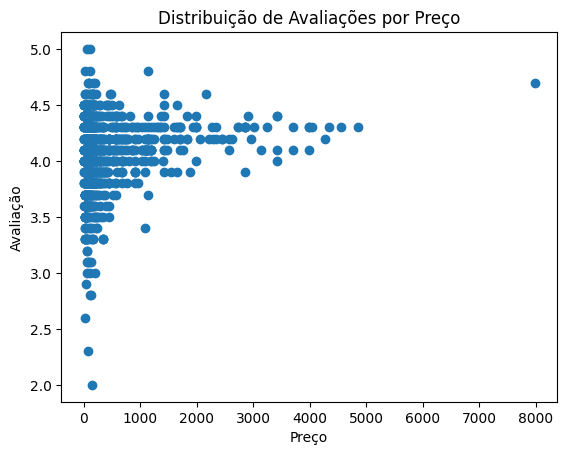

In [ ]:
plt.scatter(df_amazon_sales['actual_price'], df_amazon_sales['rating'])
plt.title("Distribuição de Avaliações por Preço")
plt.xlabel("Preço")
plt.ylabel("Avaliação")
plt.show()

In [ ]:
df_amazon_sales = df_amazon_sales.copy()

df_amazon_sales['faixa_preco'] = pd.cut(
    df_amazon_sales['actual_price'],
    bins=[0,50,100,200,500,1000,5000]
)

df_preco_rating = (
    df_amazon_sales
    .groupby('faixa_preco', observed=False)['rating']
    .agg('mean')
    .round(2)
)

df_preco_rating

,rating
faixa_preco,
"(0, 50]",4.09
"(50, 100]",4.09
"(100, 200]",4.08
"(200, 500]",4.03
"(500, 1000]",4.13
"(1000, 5000]",4.2


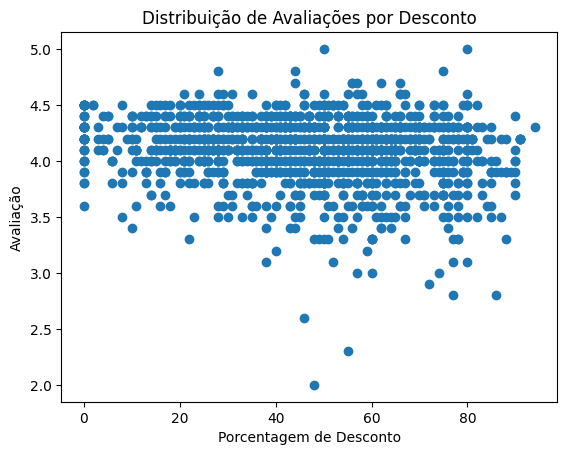

In [ ]:
plt.scatter(df_amazon_sales['discount_percentage'], df_amazon_sales['rating'])
plt.title("Distribuição de Avaliações por Desconto")
plt.xlabel("Porcentagem de Desconto")
plt.ylabel("Avaliação")
plt.show()

In [ ]:
df_amazon_sales.loc[:, 'faixa_desconto'] = pd.cut(
    df_amazon_sales['discount_percentage'],
    bins=[0,10,20,30,40,50,100]
)

df_amazon_sales.groupby('faixa_desconto', observed=False)['rating'].mean().round(2)

,rating
faixa_desconto,
"(0, 10]",4.16
"(10, 20]",4.14
"(20, 30]",4.15
"(30, 40]",4.1
"(40, 50]",4.09
"(50, 100]",4.05


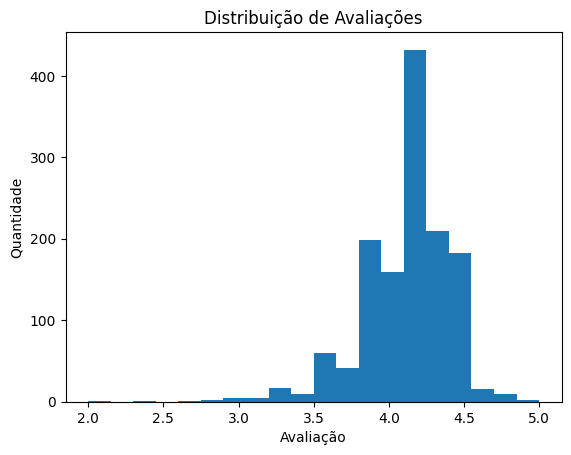

In [ ]:
plt.hist(df_amazon_sales['rating'], bins=20)
plt.title("Distribuição de Avaliações")
plt.xlabel("Avaliação")
plt.ylabel("Quantidade")
plt.show()

In [ ]:
df_amazon_sales['rating'].value_counts().sort_index()
# Quantidade de Avaliações por Nota

,count
rating,
2.0,1
2.3,1
2.6,1
2.8,2
2.9,1
3.0,3
3.1,4
3.2,2
3.3,15


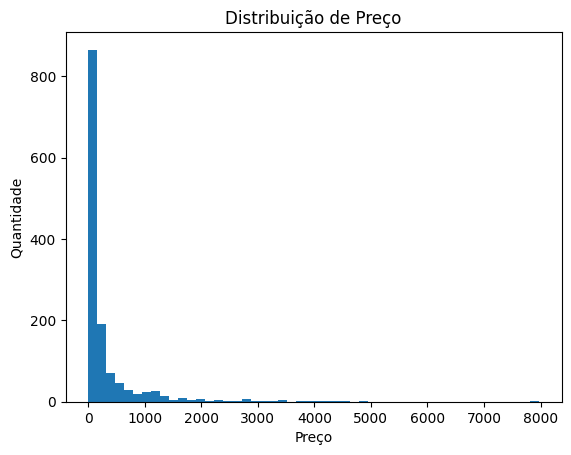

In [ ]:
plt.hist(df_amazon_sales['actual_price'], bins=50)
plt.title("Distribuição de Preço")
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.show()

In [ ]:
df_amazon_sales['faixa_preco'] = pd.cut(
    df_amazon_sales['actual_price'],
    bins=[0,50,100,200,500,1000,5000,10000]
)

df_amazon_sales.groupby(
    'faixa_preco',
    observed=False
)['actual_price'].count()

# Quantidade de Produtos por Faixa de Preço

,actual_price
faixa_preco,
"(0, 50]",327
"(50, 100]",344
"(100, 200]",276
"(200, 500]",183
"(500, 1000]",91
"(1000, 5000]",126
"(5000, 10000]",1


In [ ]:
df_cat = df_amazon_sales.explode('category')
df_cat['category'].value_counts().head(10)
# Quantidade de Produtos por Categoria

,count
category,
Electronics,490
Home&Kitchen,447
Computers&Accessories,373
Kitchen&HomeAppliances,307
Accessories&Peripherals,305
Cables,190
SmallKitchenAppliances,181
Cables&Accessories,165
USBCables,159


In [ ]:
df_media_preco_categoria = df_cat.groupby('category')['actual_price'].mean().round(2)
df_media_preco_categoria
# Preço médio po categoria

,actual_price
category,
3DGlasses,199.50
AVReceivers&Amplifiers,176.70
Accessories,76.64
Accessories&Peripherals,68.11
Adapters,99.70
...,...
WetGrinders,270.35
WireboundNotebooks,8.55
WirelessUSBAdapters,78.11


In [ ]:
df_media_avaliacao_categoria = df_cat.groupby('category')['rating'].mean().round(2)
df_media_avaliacao_categoria
# Preço médio po categoria

,rating
category,
3DGlasses,3.5
AVReceivers&Amplifiers,4.0
Accessories,4.03
Accessories&Peripherals,4.15
Adapters,4.15
...,...
WetGrinders,3.8
WireboundNotebooks,4.4
WirelessUSBAdapters,4.09


In [ ]:
df_avaliacao_categoria = df_cat.groupby('category')['rating'].count()
df_avaliacao_categoria
# Quantidade de avaliações por categoria

,rating
category,
3DGlasses,1
AVReceivers&Amplifiers,1
Accessories,105
Accessories&Peripherals,305
Adapters,4
...,...
WetGrinders,2
WireboundNotebooks,4
WirelessUSBAdapters,14


In [ ]:
df_amazon_sales.sort_values(by='discount_percentage', ascending=False).head(10)
# Produtos com maior porcentagem de desconto

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,faixa_preco,faixa_desconto
633,B097C564GC,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...","[Computers&Accessories, Accessories&Peripheral...",16.76,284.94,94,4.3,4426,【WIDER COMPATIBILITY】This USB C Female to USB ...,"[AGO5SRT3ESLNL5WTRQFD5BSIYPQA, AGGNODUMRADB3PQ...","[Naga Sai Gadagottu, Neha Sharma, Amazon Custo...","[R3CUNCZTU43JPP, RSO46BN8S4OSU, R2UD5D7T4DZRE5...","[Tiny helping hand, Good product, As a whole g...",[This eliminates the need to buy chargers for ...,"(200, 500]","(50, 100]"
369,B0BF4YBLPX,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...","[Electronics, WearableTechnology, SmartWatches]",102.54,1139.94,91,4.2,13937,Fire-Boltt is India' No 1 Wearable Watch Brand...,"[AEC6UDCEAUIBIFHGQDQ4KR67GC4A, AHRKSUOZXKKDERR...","[venkatesh kg, Raghuram, YOGESH, Manan Parmar,...","[R1PKIMKR1E8X8T, R23UV7ZBIEEZD3, RYRHNVDKS5RFY...","[Worth the money, Good smart watch, the screen...","[I liked it, worth the money, light weight a...","(1000, 5000]","(50, 100]"
375,B0BF54LXW6,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...","[Electronics, WearableTechnology, SmartWatches]",102.54,1139.94,91,4.2,13937,Fire-Boltt is India' No 1 Wearable Watch Brand...,"[AEC6UDCEAUIBIFHGQDQ4KR67GC4A, AHRKSUOZXKKDERR...","[venkatesh kg, Raghuram, YOGESH, Manan Parmar,...","[R1PKIMKR1E8X8T, R23UV7ZBIEEZD3, RYRHNVDKS5RFY...","[Worth the money, Good smart watch, the screen...","[I liked it, worth the money, light weight a...","(1000, 5000]","(50, 100]"
362,B0BF54972T,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...","[Electronics, WearableTechnology, SmartWatches]",102.54,1139.94,91,4.2,13937,Fire-Boltt is India' No 1 Wearable Watch Brand...,"[AEC6UDCEAUIBIFHGQDQ4KR67GC4A, AHRKSUOZXKKDERR...","[venkatesh kg, Raghuram, YOGESH, Manan Parmar,...","[R1PKIMKR1E8X8T, R23UV7ZBIEEZD3, RYRHNVDKS5RFY...","[Worth the money, Good smart watch, the screen...","[I liked it, worth the money, light weight a...","(1000, 5000]","(50, 100]"
366,B0BF563HB4,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...","[Electronics, WearableTechnology, SmartWatches]",102.54,1139.94,91,4.2,13937,Fire-Boltt is India' No 1 Wearable Watch Brand...,"[AEC6UDCEAUIBIFHGQDQ4KR67GC4A, AHRKSUOZXKKDERR...","[venkatesh kg, Raghuram, YOGESH, Manan Parmar,...","[R1PKIMKR1E8X8T, R23UV7ZBIEEZD3, RYRHNVDKS5RFY...","[Worth the money, Good smart watch, the screen...","[I liked it, worth the money, light weight a...","(1000, 5000]","(50, 100]"
332,B0BF57RN3K,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...","[Electronics, WearableTechnology, SmartWatches]",102.54,1139.94,91,4.2,13937,Fire-Boltt is India' No 1 Wearable Watch Brand...,"[AEC6UDCEAUIBIFHGQDQ4KR67GC4A, AHRKSUOZXKKDERR...","[venkatesh kg, Raghuram, YOGESH, Manan Parmar,...","[R1PKIMKR1E8X8T, R23UV7ZBIEEZD3, RYRHNVDKS5RFY...","[Worth the money, Good smart watch, the screen...","[I liked it, worth the money, light weight a...","(1000, 5000]","(50, 100]"
825,B08X77LM8C,"Silicone Rubber Earbuds Tips, Eartips, Earpads...","[Electronics, Headphones,Earbuds&Accessories, ...",5.64,56.94,90,3.8,594,Ultra Soft and Durable made from finest Silico...,"[AFCUW5JX2EZRGRGNHO65DGJ2ZNXA, AEK5ZL5CKQD6YJF...","[AmazonCustomermh7790, Akkuu Akshay, Zahid T.,...","[R2NZAVDD3V0QHH, RH94RL6QTX9ZG, RPERYOA7LX9AI,...","[If this is M what is S, Only Better for neckb...","[Tips are okay, but they are small. Wondering...","(50, 100]","(50, 100]"
517,B09SJ1FTYV,Sounce Protective Case Cover Compatible Boat X...,"[Electronics, Mobiles&Accessories, MobileAcces...",11.34,108.24,90,4.0,4740,COMPATIBLE: Compatible with boAt Xtend. Ultra-...,"[AHUKIXVRPVVYYRQOUGWBDYO7RFDQ, AGGFXEMEWUIDSSL...","[Gourab Kumar Patro, Amazon Customer, tuhina m...","[R1E6PBJHMY4C1G, R3JHVSY69JG16Z, R2YVWM2WLBVV3...",[Perfect fit n finish. But slightly over price...,[Perfect fit n finish. But slightly over pric

In [ ]:
df_amazon_sales.sort_values(by='discount_percentage', ascending=True).head(10)
# Produtos com menor porcentagem de desconto

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,faixa_preco,faixa_desconto
1341,B00TI8E7BI,Philips HD9306/06 1.5-Litre Electric Kettle (M...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",153.62,153.62,0,4.4,2518,"Food grade stainless steel, Frequency: 50 Hz. ...","[AHYXOMUJUKZHBWHP43ZAB265EDGA, AG4C27NTZZ7HTG6...","[AmazonCust, DD_Zen, Amazon Customer, VINISH T...","[R252H4TFMWK9L7, R3SAFGRVGD7GTV, R1FVCFYT4SGY7...","[3, Sturdy and Works Flawlessly, Excellent 👍, ...","[Cord is small and sound while heating, Well b...","(100, 200]",NaN
338,B0B3CQBRB4,"OnePlus Nord 2T 5G (Gray Shadow, 8GB RAM, 128G...","[Electronics, Mobiles&Accessories, Smartphones...",1652.94,1652.94,0,4.3,17415,Camera: 50MP Main Camera with Sony IMX766 and ...,"[AEREO7C5GLYYYV6YXK7X4UCCQTJQ, AHWISRUJUCJG6UH...","[ASR, Amazon user, Rama Rao, Vinay, ANIKET, NA...","[R128LZ0DN2NZBZ, R3LFQ7EDHZ6DKM, RUSJFUV64DPWM...",[Really a Good Buy in this price range in 2022...,[Verdict : A Solid buy for this price segment ...,"(1000, 5000]",NaN
398,B0B3D39RKV,"OnePlus Nord 2T 5G (Jade Fog, 12GB RAM, 256GB ...","[Electronics, Mobiles&Accessories, Smartphones...",1937.94,1937.94,0,4.3,17415,Camera: 50MP Main Camera with Sony IMX766 and ...,"[AEREO7C5GLYYYV6YXK7X4UCCQTJQ, AHWISRUJUCJG6UH...","[ASR, Amazon user, Rama Rao, Vinay, ANIKET, NA...","[R128LZ0DN2NZBZ, R3LFQ7EDHZ6DKM, RUSJFUV64DPWM...",[Really a Good Buy in this price range in 2022...,[Verdict : A Solid buy for this price segment ...,"(1000, 5000]",NaN
1188,B012ELCYUG,Preethi MGA-502 0.4-Litre Grind and Store Jar ...,"[Home&Kitchen, Kitchen&HomeAppliances, SmallKi...",36.20,36.20,0,4.3,4570,"Country of Origin: India|Capacity: 0.4 liters,...","[AGC3Z3473ZVXYFMWYSAUE2T7V3MA, AEDXKCO2L3ULRQJ...","[Sunil Khandagale, Shamim, HARI.M, Malini, Kus...","[RN9VBZPCHG67H, RSK3T9GASN96L, RPWBSG3KWA82A, ...","[Good, Goos product which you can trust, Good,...","[You can buy a good product., Purchased this s...","(0, 50]",NaN
589,B0846D5CBP,Casio FX-991ES Plus-2nd Edition Scientific Cal...,"[OfficeProducts, OfficeElectronics, Calculator...",73.82,73.82,0,4.5,5760,Redesigned ES PLUS series calculators featurin...,"[AFES6HMBN5CAV5HWKASX5HS743BA, AE2SYKBDNNE4PVO...","[Vajrala s., Goutham.G.A., Abhishek Kumar Shar...","[R2MYHLYRBQ49CU, R1ZYG8KT7IKN0F, R1CPM2M1SFJD0...","[Nice, Good and light calculator, Cheap button...","[It is very easy to use., Good and easy to use...","(50, 100]",NaN
645,B08TDJNM3G,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,"[Computers&Accessories, Accessories&Peripheral...",3.36,3.36,0,3.8,5958,"Portable, easy to use|LED lights for maximum i...","[AEJGZNKM5ZGH6UY2YX537NWNWYDQ, AGZGGK6OUCCSLXO...","[Ravi Kumar s/o Devraj, anil-kumar, Soumith, D...","[R3CEIRJ8YFRONO, R3ICE0RT3T14TH, R17764XIRZDB5...","[Good, Product as described, Good for the pric...","[Good, Product is as described, good we can u...","(0, 50]",NaN
667,B0752LL57V,Casio MJ-12D 150 Steps Check and Correct Deskt...,"[OfficeProducts, OfficeElectronics, Calculator...",25.08,25.08,0,4.5,8610,"Regular keys like %, square root and Memory|De...","[AFCKVOFM46DHVEVU7M4ABUCXDLLQ, AH6ROKDEOWF5LFG...","[Dipu, Kayumuddin, Ankit salunke AS, Ramachand...","[R3S29FN21O2CMZ, R11MO8HH0GUD1M, R3TQJKN7EJKGX...","[Very easy to use, Easy to use ., Best calcula...","[Very good, Nice product, https://m.media-amaz...","(0, 50]",NaN
576,B07KCMR8D6,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,"[OfficeProducts, OfficePaperProducts, Paper, S...",2.85,2.85,0,4.3,5792,5 vibrant Neon body color|Smooth and fast writ...,"[AEVPRYZLGHNMEZA5BYGIX36LYZXA, AEZPOZQEEBFFXZ2...","[Gatij saini, Biswajit Kundu, Altaf Khan, Agam...","[RZAAQFY7BDSWC, R3604ZO2AA4PK5, R3C8K6Z6W9MDTQ...","[Nice ball pen, Good product, Average, Nice Pe...","[Very nice ball pen, Thank you Amazon, Easy to...","(0, 50]",NaN
766,B07SBGFDX9,"Pentonic Multicolor Ball Point Pen, Pack of

# Exportação do DataFrame Tratado

In [ ]:
df_amazon_sales.to_csv('amazon_sales_clean.csv', index=False)
# Arquivo .csv tratado

In [ ]:
df_amazon_sales.to_excel("amazon_sales.xlsx", index=False)
# Arquivo excel tratado

In [ ]:
df_media_preco_categoria.to_excel("media_preco_categoria.xlsx")
# Arquivo excel com média de preço por categoria

In [ ]:
df_media_avaliacao_categoria.to_excel("media_avaliacao_categoria.xlsx")
# Arquivo excel com média de avaliação por categoria

In [ ]:
df_avaliacao_categoria.to_excel("avaliacao_categoria.xlsx")
# Arquivo excel com quantidade de avaliações por categoria

# Modelagem Preditiva, Algoritmos de Machine Learning e Métricas de Avaliação de Modelos

R²:   0.0117
RMSE: 0.3167
Coeficientes → actual_price: 0.000049 | discount_percentage: -0.002242
Intercepto: 4.1839


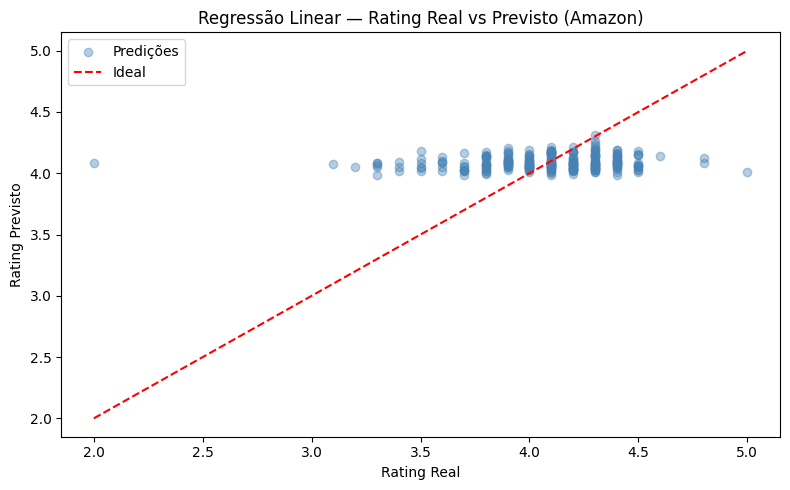

In [ ]:
X = df_amazon_sales[['actual_price', 'discount_percentage']].dropna()
y = df_amazon_sales.loc[X.index, 'rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred = modelo_lr.predict(X_test)

print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficientes → actual_price: {modelo_lr.coef_[0]:.6f} | discount_percentage: {modelo_lr.coef_[1]:.6f}")
print(f"Intercepto: {modelo_lr.intercept_:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', label='Predições')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel("Rating Real")
plt.ylabel("Rating Previsto")
plt.title("Regressão Linear — Rating Real vs Previsto (Amazon)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Criar variável binária: 1 se rating >= 4, 0 caso contrário
df_log = df_amazon_sales[['actual_price', 'discount_percentage', 'rating_count', 'rating']].dropna().copy()
df_log['bom_produto'] = (df_log['rating'] >= 4).astype(int)

X_log = df_log[['actual_price', 'discount_percentage', 'rating_count']]
y_log = df_log['bom_produto']

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

X_train, X_test, y_train, y_test = train_test_split(X_log_scaled, y_log, test_size=0.2, random_state=42)

modelo_logit = LogisticRegression(max_iter=1000)
modelo_logit.fit(X_train, y_train)
y_pred_log = modelo_logit.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print(f"Acurácia: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=['Rating < 4', 'Rating >= 4']))

Acurácia: 0.7111
              precision    recall  f1-score   support

  Rating < 4       0.00      0.00      0.00        78
 Rating >= 4       0.71      1.00      0.83       192

    accuracy                           0.71       270
   macro avg       0.36      0.50      0.42       270
weighted avg       0.51      0.71      0.59       270



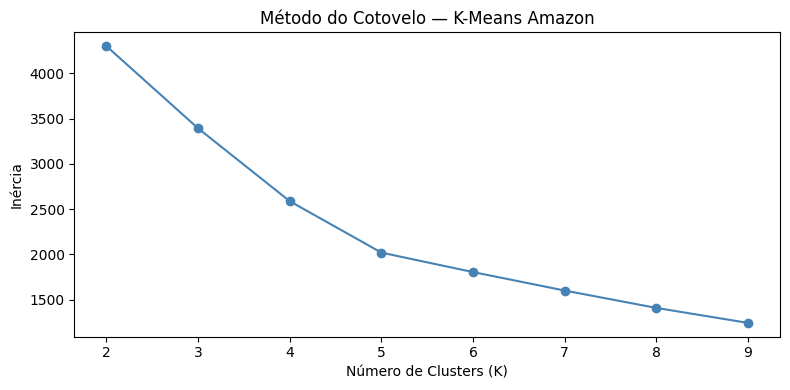

         preco_medio  desconto_medio  rating_medio  n_reviews_medio  \
cluster                                                               
0             238.86           28.25          4.22         12207.67   
1             139.62           46.41          4.15        219400.59   
2            2395.04           37.51          4.25         11584.02   
3             160.86           61.53          3.97         11232.58   

         n_produtos  
cluster              
0               526  
1                39  
2                81  
3               702  


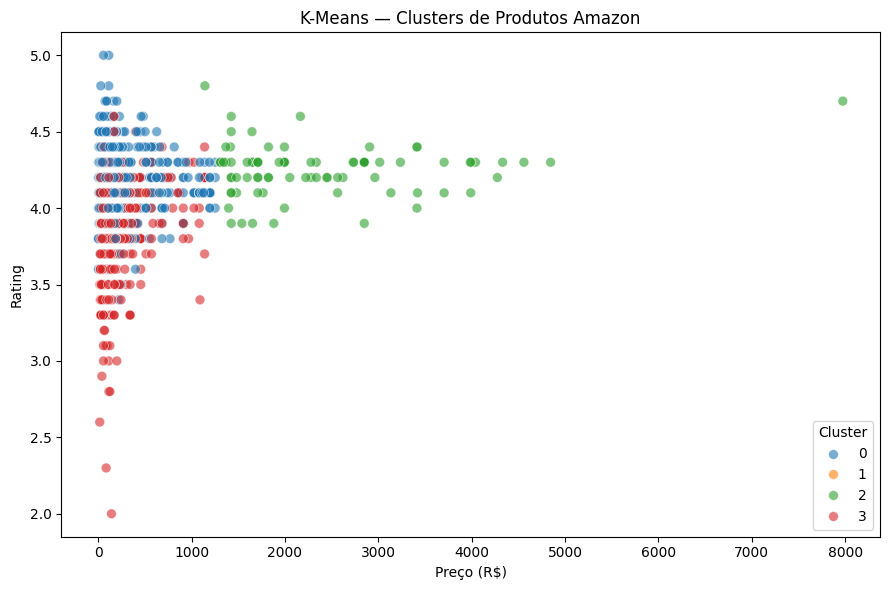

In [ ]:
df_kmeans = df_amazon_sales[['actual_price', 'discount_percentage', 'rating', 'rating_count']].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_kmeans)

# Método do cotovelo para escolher K
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo — K-Means Amazon")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# Aplicar com K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_kmeans['cluster'] = kmeans.fit_predict(X_scaled)

# Perfil de cada cluster
print(df_kmeans.groupby('cluster').agg(
    preco_medio=('actual_price', 'mean'),
    desconto_medio=('discount_percentage', 'mean'),
    rating_medio=('rating', 'mean'),
    n_reviews_medio=('rating_count', 'mean'),
    n_produtos=('rating', 'count')
).round(2))

# Scatter plot dos clusters
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_kmeans, x='actual_price', y='rating',
                hue='cluster', palette='tab10', alpha=0.6, s=50)
plt.title("K-Means — Clusters de Produtos Amazon")
plt.xlabel("Preço (R$)")
plt.ylabel("Rating")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

Clusters encontrados: 3
Outliers detectados:  20


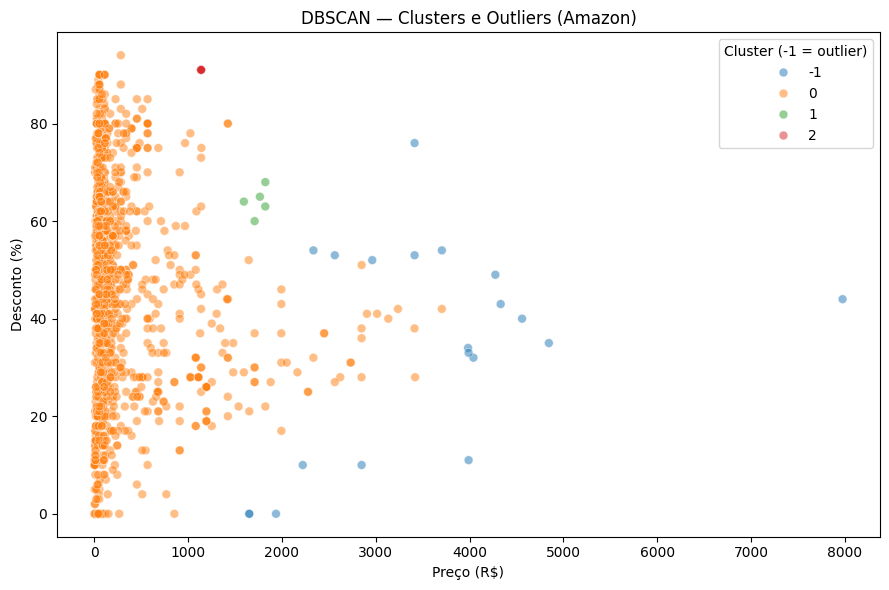

In [ ]:
df_db = df_amazon_sales[['actual_price', 'discount_percentage']].dropna().copy()
X_db = StandardScaler().fit_transform(df_db)

dbscan = DBSCAN(eps=0.5, min_samples=5)
df_db['cluster_db'] = dbscan.fit_predict(X_db)

n_clusters = len(set(df_db['cluster_db'])) - (1 if -1 in df_db['cluster_db'].values else 0)
n_outliers  = (df_db['cluster_db'] == -1).sum()
print(f"Clusters encontrados: {n_clusters}")
print(f"Outliers detectados:  {n_outliers}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_db, x='actual_price', y='discount_percentage',
                hue='cluster_db', palette='tab10', alpha=0.5, s=40)
plt.title("DBSCAN — Clusters e Outliers (Amazon)")
plt.xlabel("Preço (R$)")
plt.ylabel("Desconto (%)")
plt.legend(title="Cluster (-1 = outlier)")
plt.tight_layout()
plt.show()

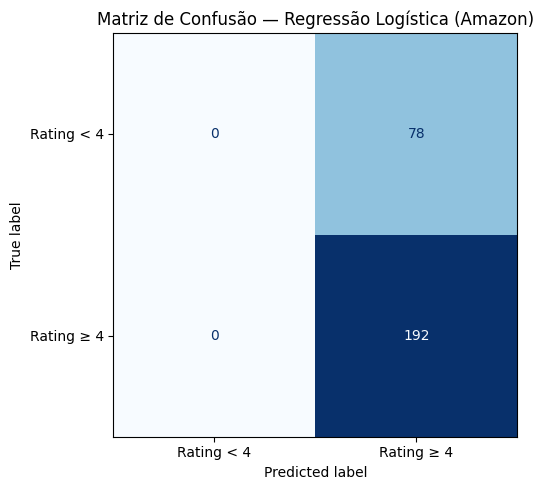

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Rating < 4', 'Rating ≥ 4'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Matriz de Confusão — Regressão Logística (Amazon)")
plt.tight_layout()
plt.show()

#DataSets Brasileiros

##Tratamento de Dados

In [ ]:
df_br_products = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_products_dataset.csv")#
df_br_customers = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_customers_dataset.csv")#
df_br_location = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_geolocation_dataset.csv")#
df_br_payments = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_order_payments_dataset.csv")#
df_br_items = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_order_items_dataset.csv")#
df_br_reviews = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_order_reviews_dataset.csv")#
df_br_orders = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_orders_dataset.csv")#
df_br_sellers = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/olist_sellers_dataset.csv")
df_br_category = pd.read_csv("/content/drive/MyDrive/Dataset ciência de dados/product_category_name_translation.csv")

In [ ]:
df_br_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
df_br_products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
df_br_products[df_br_products.isna().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [ ]:
df_br_products[df_br_products.duplicated(subset=['product_id'])]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [ ]:
df_br_products = df_br_products.dropna()

In [ ]:
df_br_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_br_customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [ ]:
df_br_customers[df_br_customers.duplicated()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [ ]:
df_br_location.isna().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [ ]:
df_br_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
df_br_items[df_br_items.duplicated()]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [ ]:
df_br_payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
df_br_payments[df_br_payments.duplicated(subset=['order_id'])]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
1456,683bf306149bb869980b68d48a1bd6ab,1,credit_card,1,8.58
2324,e6a66a8350bb88497954d37688ab123e,2,voucher,1,10.51
2393,8e5148bee82a7e42c5f9ba76161dc51a,1,credit_card,1,0.67
2414,816ccd9d21435796e8ffa9802b2a782f,1,credit_card,1,5.65
2497,2cbcb371aee438c59b722a21d83597e0,2,voucher,1,7.80
...,...,...,...,...,...
103778,fd86c80924b4be8fb7f58c4ecc680dae,1,credit_card,1,76.10
103817,6d4616de4341417e17978fe57aec1c46,1,credit_card,1,19.18
103860,31bc09fdbd701a7a4f9b55b5955b8687,6,voucher,1,77.99
103869,c9b01bef18eb84888f0fd071b8413b38,1,credit_card,6,238.16


In [ ]:
df_br_payments = df_br_payments.drop_duplicates(subset=['order_id']).reset_index(drop=True)

In [ ]:
df_br_reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
df_br_reviews = df_br_reviews.drop(columns=['review_comment_title', 'review_comment_message'])

In [ ]:
df_br_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
df_br_orders = df_br_orders.drop(columns=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'])

In [ ]:
df_br_sellers.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
df_br_category.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [ ]:
# ── Tradução de categorias ──────────────────────────────────
df_br_products = df_br_products.merge(df_br_category, on='product_category_name', how='left')
df_br_products['category'] = df_br_products['product_category_name_english'].fillna(
    df_br_products['product_category_name'].fillna('unknown')
)

# ── Conversão de datas ──────────────────────────────────────
df_br_orders['order_purchase_timestamp'] = pd.to_datetime(
    df_br_orders['order_purchase_timestamp'], errors='coerce'
)
df_br_orders['order_estimated_delivery_date'] = pd.to_datetime(
    df_br_orders['order_estimated_delivery_date'], errors='coerce'
)

# ── Geolocalização sem duplicatas ───────────────────────────
df_br_location = df_br_location.drop_duplicates(subset=['geolocation_zip_code_prefix'])

# ── Merge principal: itens → pedidos → clientes → produtos → vendedores ──
base = (df_br_items
        .merge(df_br_orders[['order_id', 'customer_id', 'order_status',
                              'order_purchase_timestamp',
                              'order_estimated_delivery_date']],
               on='order_id', how='left')
        .merge(df_br_customers[['customer_id', 'customer_state', 'customer_city']],
               on='customer_id', how='left')
        .merge(df_br_products[['product_id', 'category']],
               on='product_id', how='left')
        .merge(df_br_sellers[['seller_id', 'seller_state']],
               on='seller_id', how='left')
)

# ── Review médio por pedido ─────────────────────────────────
review_agg = df_br_reviews.groupby('order_id')['review_score'].mean().reset_index()
base = base.merge(review_agg, on='order_id', how='left')

# ── Pagamento total por pedido → calcular desconto ──────────
pay_agg = (df_br_payments.groupby('order_id')['payment_value']
           .sum().reset_index().rename(columns={'payment_value': 'total_paid'}))
base = base.merge(pay_agg, on='order_id', how='left')

order_totals = base.groupby('order_id').agg(
    order_price=('price', 'sum'),
    order_freight=('freight_value', 'sum')
).reset_index()
order_totals['order_subtotal'] = order_totals['order_price'] + order_totals['order_freight']
base = base.merge(order_totals[['order_id', 'order_subtotal']], on='order_id', how='left')

base['discount_value'] = np.where(
    base['order_subtotal'] > 0,
    np.clip(
        (base['order_subtotal'] - base['total_paid'])
        * (base['price'] / base['order_subtotal'].replace(0, np.nan)),
        0, None
    ),
    0
)
base['discount_pct'] = np.where(
    base['price'] > 0,
    np.clip(base['discount_value'] / base['price'] * 100, 0, 100),
    0
)

# ── Base filtrada apenas com pedidos entregues ──────────────
base_delivered = base[base['order_status'] == 'delivered'].copy()

print(f"Base consolidada (all):       {base.shape}")
print(f"Base consolidada (delivered): {base_delivered.shape}")

Base consolidada (all):       (112650, 20)
Base consolidada (delivered): (110197, 20)


# Análise de Dados (KPIs)

In [ ]:
def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_title(title, color='#ffffff', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color='#b0b0c0', fontsize=10)
    ax.set_ylabel(ylabel, color='#b0b0c0', fontsize=10)
    ax.tick_params(colors='#a0a0b0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#2d3148')
    ax.spines['bottom'].set_color('#2d3148')
    ax.grid(True, axis='y', alpha=0.3, color='#2d3148')
    return ax

def add_bar_labels(ax, fmt='{:.0f}', color='#e0e0e0', fontsize=8.5, rotation=0):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(
                fmt.format(h),
                (p.get_x() + p.get_width() / 2., h),
                ha='center', va='bottom', fontsize=fontsize,
                color=color, rotation=rotation,
                xytext=(0, 3), textcoords='offset points'
            )

def section_banner(title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")

In [ ]:
# ── KPI 1 – Preço médio dos produtos ───────────────────────
avg_price = df_br_items['price'].mean()
print(f"[KPI 1] Preço médio dos produtos: R$ {avg_price:.2f}")

# ── KPI 2 – Preço médio por categoria ──────────────────────
avg_price_cat = (base_delivered.groupby('category')['price']
                 .mean()
                 .sort_values(ascending=False)
                 .reset_index()
                 .rename(columns={'price': 'avg_price'}))
print(f"\n[KPI 2] Preço médio por categoria (top 10):")
print(avg_price_cat.head(10).to_string(index=False))

# ── KPI 3 – Preço máximo ────────────────────────────────────
max_price = df_br_items['price'].max()
print(f"\n[KPI 3] Preço máximo: R$ {max_price:.2f}")

# ── KPI 4 – Preço mínimo + desvio padrão ───────────────────
min_price = df_br_items['price'].min()
std_price  = df_br_items['price'].std()
print(f"[KPI 4] Preço mínimo: R$ {min_price:.2f}")
print(f"[KPI 4] Desvio padrão de preços: R$ {std_price:.2f}")

# ── KPI 5 – Percentual médio de desconto ────────────────────
avg_disc_pct = base_delivered['discount_pct'].mean()
print(f"\n[KPI 5] Percentual médio de desconto: {avg_disc_pct:.2f}%")

# ── KPI 6 – Valor médio de desconto ─────────────────────────
avg_disc_val = base_delivered['discount_value'].mean()
print(f"[KPI 6] Valor médio de desconto: R$ {avg_disc_val:.2f}")

# ── KPI 7 – Produtos com maior desconto (top 10) ────────────
prod_discount = (base_delivered.groupby('product_id')
                 .agg(avg_discount_pct=('discount_pct', 'mean'),
                      avg_price=('price', 'mean'),
                      n_vendas=('order_id', 'count'))
                 .reset_index()
                 .sort_values('avg_discount_pct', ascending=False))

print(f"\n[KPI 7] Top 10 produtos com maior desconto:")
print(prod_discount.head(10)[['product_id', 'avg_discount_pct', 'avg_price', 'n_vendas']].to_string(index=False))

# ── KPI 8 – Produtos com menor desconto (excluindo zero) ────
prod_discount_sem_zero = prod_discount[prod_discount['avg_discount_pct'] > 0]
print(f"\n[KPI 8] Top 10 produtos com menor desconto (> 0%):")
print(prod_discount_sem_zero.tail(10)[['product_id', 'avg_discount_pct', 'avg_price']].to_string(index=False))

[KPI 1] Preço médio dos produtos: R$ 120.65

[KPI 2] Preço médio por categoria (top 10):
                                     category   avg_price
                                    computers 1098.915276
        small_appliances_home_oven_and_coffee  638.213151
                            home_appliances_2  467.333117
                   agro_industry_and_commerce  342.553883
                          musical_instruments  283.127097
portateis_cozinha_e_preparadores_de_alimentos  280.973571
                             small_appliances  277.741824
                              fixed_telephony  216.922392
                    construction_tools_safety  211.875519
                                watches_gifts  199.040276

[KPI 3] Preço máximo: R$ 6735.00
[KPI 4] Preço mínimo: R$ 0.85
[KPI 4] Desvio padrão de preços: R$ 183.63

[KPI 5] Percentual médio de desconto: 1.59%
[KPI 6] Valor médio de desconto: R$ 1.97

[KPI 7] Top 10 produtos com maior desconto:
                      product_id  a

In [ ]:
# ── KPI 9 – Rating médio dos produtos ───────────────────────
avg_rating = base_delivered['review_score'].mean()
print(f"[KPI 9]  Rating médio dos produtos: {avg_rating:.2f} ⭐")

# ── KPI 10 – Rating médio por categoria (mín. 50 reviews) ───
avg_rating_cat = (base_delivered.groupby('category')['review_score']
                  .agg(['mean', 'count'])
                  .reset_index()
                  .rename(columns={'mean': 'avg_rating', 'count': 'n_reviews'})
                  .query('n_reviews >= 50')
                  .sort_values('avg_rating', ascending=False))
print(f"\n[KPI 10] Rating médio por categoria (top 10):")
print(avg_rating_cat.head(10).to_string(index=False))

# ── KPI 11 – Produtos com maior rating (mín. 10 reviews) ────
prod_rating = (base_delivered.groupby('product_id')['review_score']
               .agg(['mean', 'count'])
               .reset_index()
               .rename(columns={'mean': 'avg_rating', 'count': 'n_reviews'})
               .query('n_reviews >= 10')
               .sort_values('avg_rating', ascending=False))
print(f"\n[KPI 11] Top 10 produtos com maior rating:")
print(prod_rating.head(10).to_string(index=False))

# ── KPI 12 – Produtos com menor rating (mín. 10 reviews) ────
print(f"\n[KPI 12] Top 10 produtos com menor rating:")
print(prod_rating.sort_values('avg_rating').head(10).to_string(index=False))

# ── KPI 13 – Produtos com maior número de reviews ───────────
top_reviews = (base_delivered.groupby('product_id')['review_score']
               .count()
               .reset_index()
               .rename(columns={'review_score': 'n_reviews'})
               .sort_values('n_reviews', ascending=False))
print(f"\n[KPI 13] Top 10 produtos com mais reviews:")
print(top_reviews.head(10).to_string(index=False))

# ── KPI 14 – Distribuição de ratings ────────────────────────
rating_dist = df_br_reviews['review_score'].value_counts().sort_index()
print(f"\n[KPI 14] Distribuição de ratings:")
print(rating_dist.to_string())

# ── KPI 15 – Correlação rating vs preço ─────────────────────
corr_rp = base_delivered[['review_score', 'price']].corr().iloc[0, 1]
print(f"\n[KPI 15] Correlação rating vs preço: {corr_rp:.4f}")

# ── KPI 16 – Correlação rating vs desconto ──────────────────
corr_rd = base_delivered[['review_score', 'discount_pct']].corr().iloc[0, 1]
print(f"[KPI 16] Correlação rating vs desconto: {corr_rd:.4f}")

[KPI 9]  Rating médio dos produtos: 4.08 ⭐

[KPI 10] Rating médio por categoria (top 10):
                             category  avg_rating  n_reviews
               books_general_interest    4.512195        533
                       books_imported    4.508772         57
              costruction_tools_tools    4.444444         99
small_appliances_home_oven_and_coffee    4.438356         73
                      books_technical    4.389313        262
                           food_drink    4.366171        269
                  luggage_accessories    4.352283       1073
                        fashion_shoes    4.290514        253
                           cine_photo    4.285714         70
                                 food    4.262834        487

[KPI 11] Top 10 produtos com maior rating:
                      product_id  avg_rating  n_reviews
59c1840441f4df065f52760bf51a8442         5.0         11
6ee7217ab647f3c2b4a5161c75cadab3         5.0         11
16ce899c7af0c99f46948734a0d

In [ ]:
# ── KPI 17 – Número total de produtos ───────────────────────
n_products = df_br_products['product_id'].nunique()
print(f"[KPI 17] Número total de produtos: {n_products:,}")

# ── KPI 18 – Número de categorias ───────────────────────────
n_categories = df_br_products['category'].nunique()
print(f"[KPI 18] Número de categorias: {n_categories}")

# ── KPI 19 – Produtos por categoria ─────────────────────────
prods_per_cat = (df_br_products.groupby('category')['product_id']
                 .count()
                 .sort_values(ascending=False)
                 .reset_index()
                 .rename(columns={'product_id': 'n_products'}))
print(f"\n[KPI 19] Produtos por categoria (top 10):")
print(prods_per_cat.head(10).to_string(index=False))

# ── KPI 20 – Categoria com maior número de produtos ─────────
top_cat = prods_per_cat.iloc[0]
print(f"\n[KPI 20] Categoria com mais produtos: {top_cat['category']} ({top_cat['n_products']} produtos)")

# ── KPI 21 – Produto mais caro ───────────────────────────────
prod_prices = df_br_items.groupby('product_id')['price'].max().reset_index()
mais_caro = prod_prices.sort_values('price', ascending=False).iloc[0]
print(f"\n[KPI 21] Produto mais caro:   ID {mais_caro['product_id']} — R$ {mais_caro['price']:.2f}")

# ── KPI 22 – Produto mais barato ────────────────────────────
mais_barato = prod_prices.sort_values('price').iloc[0]
print(f"[KPI 22] Produto mais barato: ID {mais_barato['product_id']} — R$ {mais_barato['price']:.2f}")

# ── KPI 23 – Produto mais avaliado (maior nº de reviews) ────
mais_avaliado = top_reviews.iloc[0]
print(f"\n[KPI 23] Produto mais avaliado: ID {mais_avaliado['product_id']} ({mais_avaliado['n_reviews']} reviews)")

# ── KPI 24 – Produto com melhor avaliação ───────────────────
melhor_avaliado = prod_rating.iloc[0]
print(f"[KPI 24] Produto com melhor avaliação: ID {melhor_avaliado['product_id']} (rating {melhor_avaliado['avg_rating']:.2f} ⭐)")

# ── KPI 25 – Reviews por categoria ──────────────────────────
reviews_per_cat = (base_delivered.groupby('category')['review_score']
                   .count()
                   .sort_values(ascending=False)
                   .reset_index()
                   .rename(columns={'review_score': 'n_reviews'}))
print(f"\n[KPI 25] Reviews por categoria (top 10):")
print(reviews_per_cat.head(10).to_string(index=False))

[KPI 17] Número total de produtos: 32,340
[KPI 18] Número de categorias: 73

[KPI 19] Produtos por categoria (top 10):
             category  n_products
       bed_bath_table        3029
       sports_leisure        2867
      furniture_decor        2657
        health_beauty        2444
           housewares        2335
                 auto        1900
computers_accessories        1639
                 toys        1411
        watches_gifts        1329
            telephony        1134

[KPI 20] Categoria com mais produtos: bed_bath_table (3029 produtos)

[KPI 21] Produto mais caro:   ID 489ae2aa008f021502940f251d4cce7f — R$ 6735.00
[KPI 22] Produto mais barato: ID 8a3254bee785a526d548a81a9bc3c9be — R$ 0.85

[KPI 23] Produto mais avaliado: ID aca2eb7d00ea1a7b8ebd4e68314663af (517 reviews)
[KPI 24] Produto com melhor avaliação: ID 59c1840441f4df065f52760bf51a8442 (rating 5.00 ⭐)

[KPI 25] Reviews por categoria (top 10):
             category  n_reviews
       bed_bath_table      10831

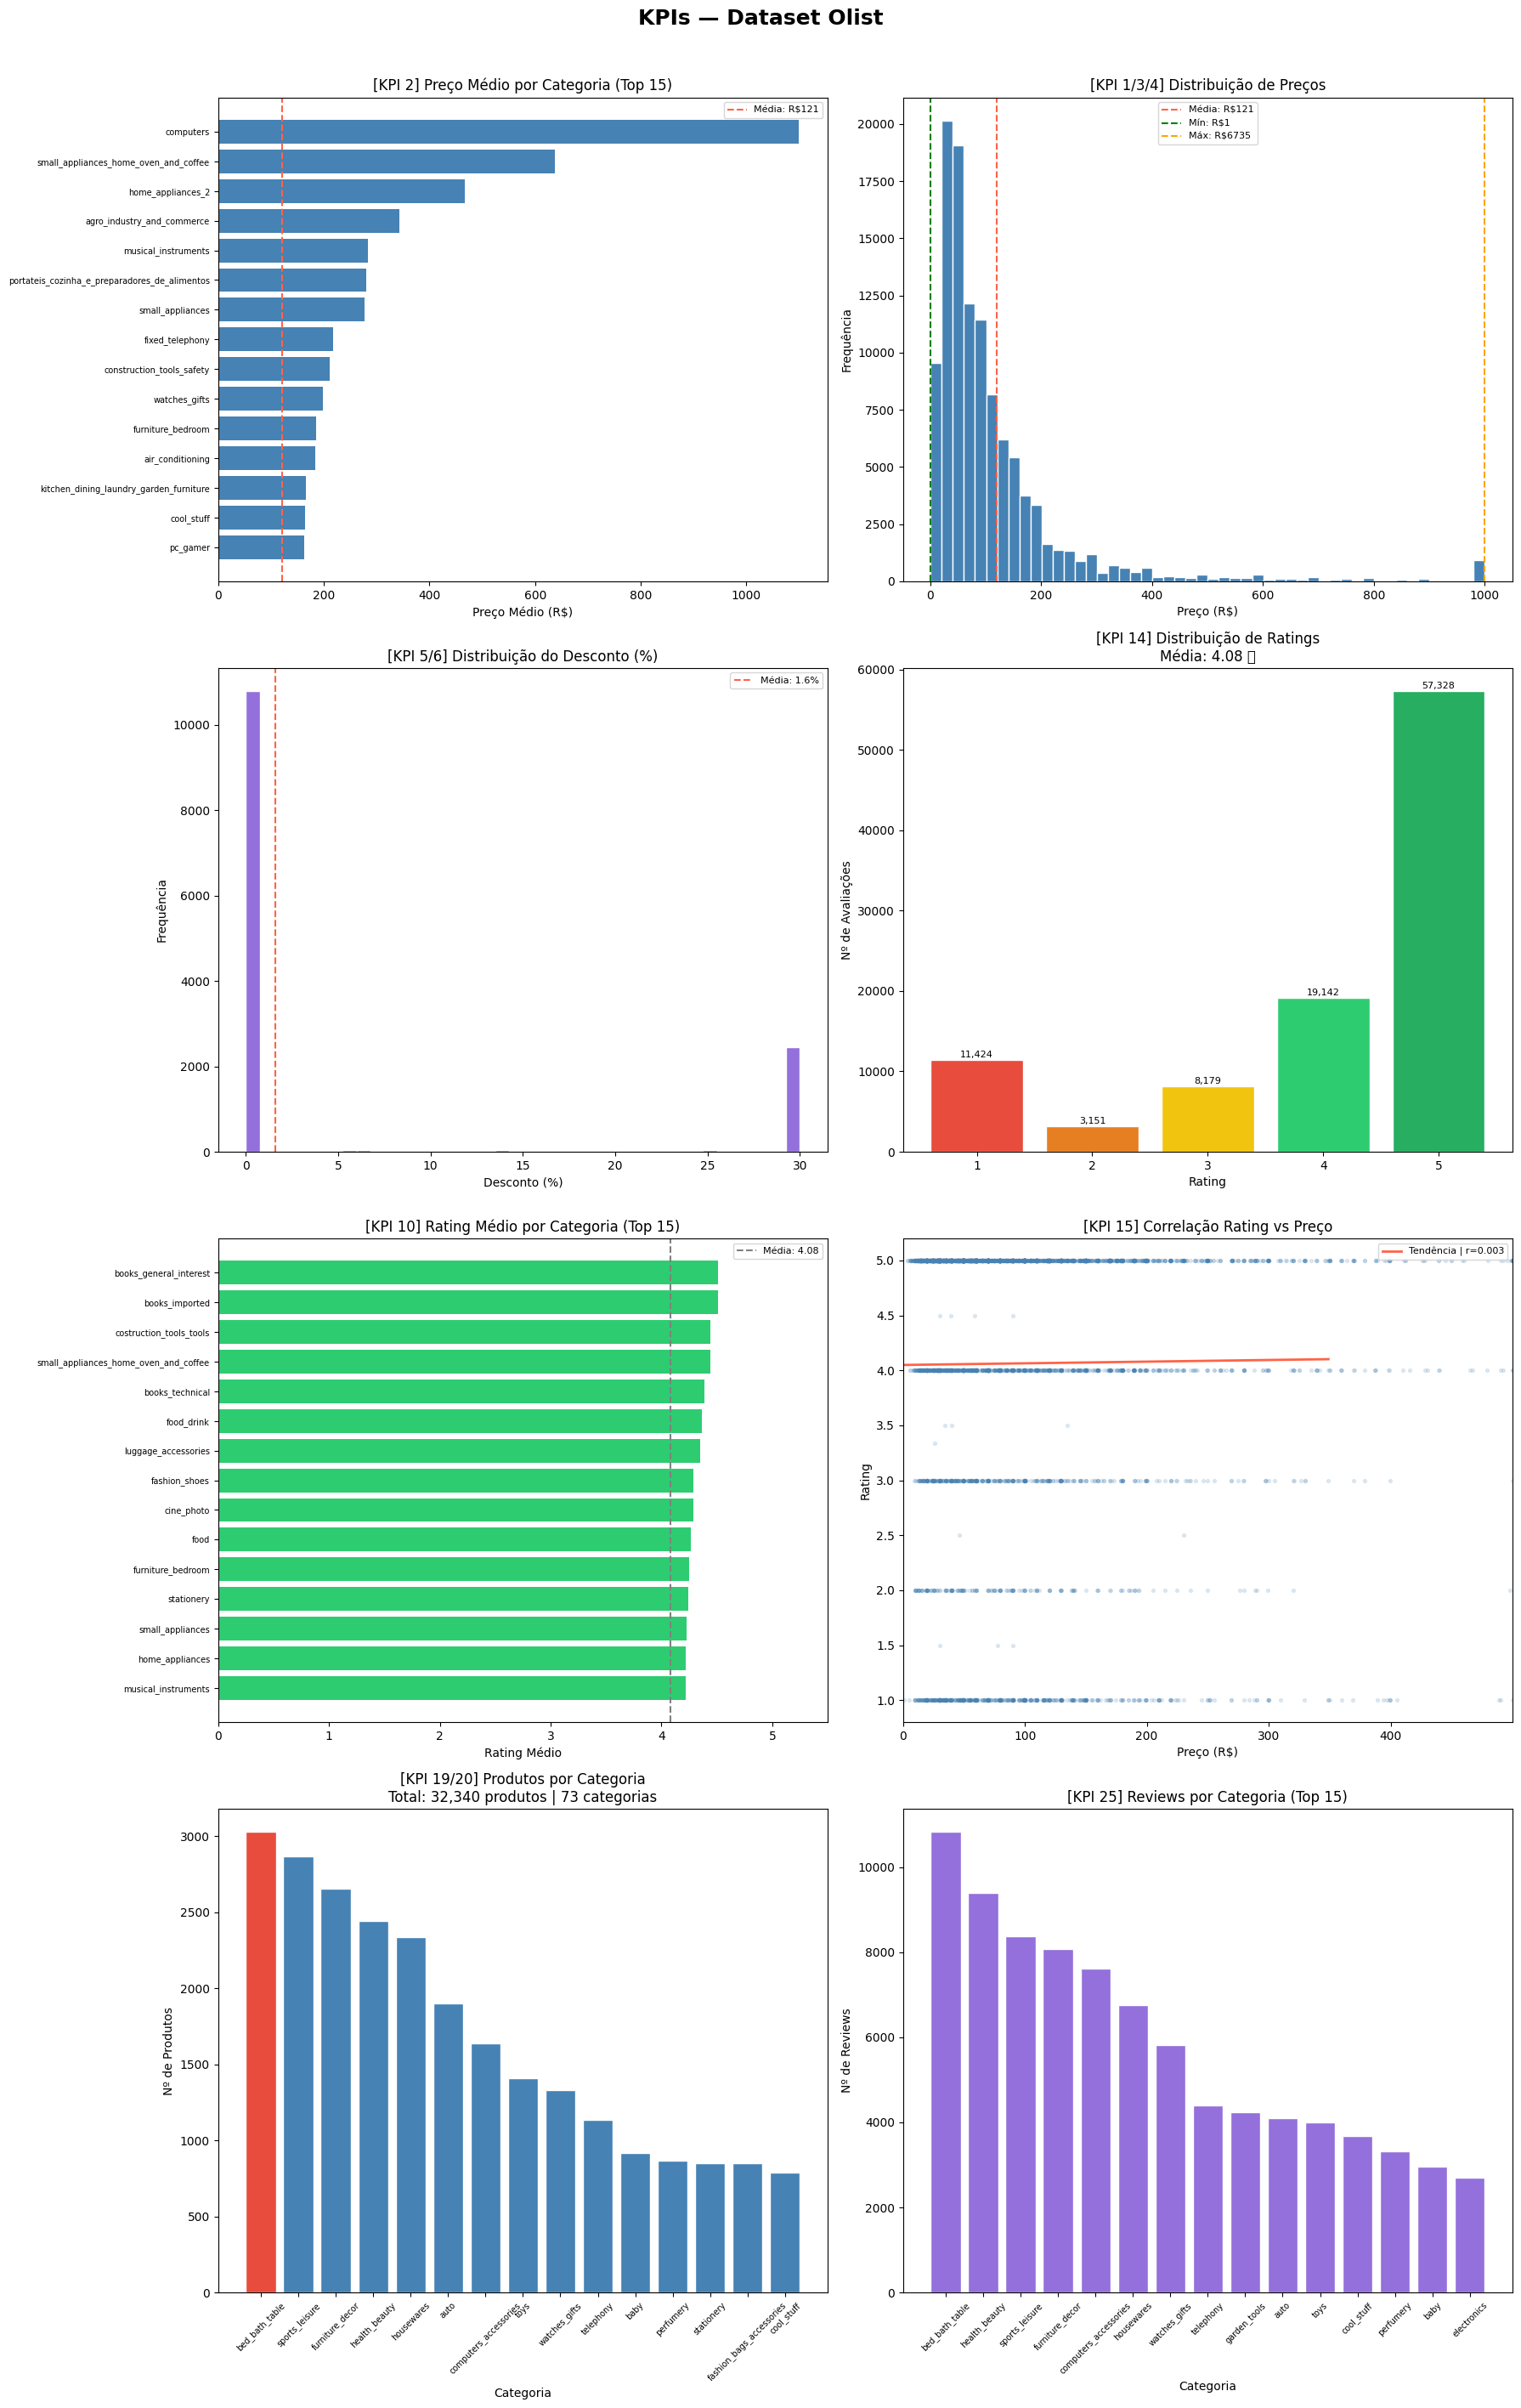

Gráfico salvo como kpis_olist.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 28))
fig.suptitle('KPIs — Dataset Olist', fontsize=18, fontweight='bold', y=1.01)
plt.subplots_adjust(hspace=0.55, wspace=0.35)

# ── Gráfico 1: KPI 2 — Preço médio por categoria (top 15) ───
ax = axes[0, 0]
top15 = avg_price_cat.head(15)
ax.barh(top15['category'][::-1], top15['avg_price'][::-1], color='steelblue')
ax.axvline(avg_price, color='tomato', linestyle='--', label=f'Média: R${avg_price:.0f}')
ax.set_title('[KPI 2] Preço Médio por Categoria (Top 15)')
ax.set_xlabel('Preço Médio (R$)')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=7)

# ── Gráfico 2: KPI 4 — Distribuição de preços ───────────────
ax = axes[0, 1]
ax.hist(df_br_items['price'].clip(upper=1000), bins=50, color='steelblue', edgecolor='white')
ax.axvline(avg_price, color='tomato',  linestyle='--', label=f'Média: R${avg_price:.0f}')
ax.axvline(min_price, color='green',   linestyle='--', label=f'Mín: R${min_price:.0f}')
ax.axvline(max_price if max_price <= 1000 else 1000,
           color='orange', linestyle='--', label=f'Máx: R${max_price:.0f}')
ax.set_title('[KPI 1/3/4] Distribuição de Preços')
ax.set_xlabel('Preço (R$)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=8)

# ── Gráfico 3: KPI 5/6 — Distribuição do desconto ───────────
ax = axes[1, 0]
disc_nonzero = base_delivered['discount_pct']
disc_nonzero = disc_nonzero[disc_nonzero > 0].clip(upper=30)
ax.hist(disc_nonzero, bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(avg_disc_pct, color='tomato', linestyle='--',
           label=f'Média: {avg_disc_pct:.1f}%')
ax.set_title('[KPI 5/6] Distribuição do Desconto (%)')
ax.set_xlabel('Desconto (%)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=8)

# ── Gráfico 4: KPI 14 — Distribuição de ratings ─────────────
ax = axes[1, 1]
cores = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
ax.bar(rating_dist.index, rating_dist.values, color=cores, edgecolor='white')
ax.set_title(f'[KPI 14] Distribuição de Ratings\nMédia: {avg_rating:.2f} ⭐')
ax.set_xlabel('Rating')
ax.set_ylabel('Nº de Avaliações')
ax.set_xticks([1, 2, 3, 4, 5])
for i, (xi, yi) in enumerate(zip(rating_dist.index, rating_dist.values)):
    ax.text(xi, yi + 300, f'{yi:,}', ha='center', fontsize=8)

# ── Gráfico 5: KPI 10 — Rating médio por categoria ──────────
ax = axes[2, 0]
top15_rat = avg_rating_cat.head(15)
cores_rat = ['#2ecc71' if v >= avg_rating else '#e74c3c' for v in top15_rat['avg_rating']]
ax.barh(top15_rat['category'][::-1], top15_rat['avg_rating'][::-1], color=cores_rat[::-1])
ax.axvline(avg_rating, color='gray', linestyle='--', label=f'Média: {avg_rating:.2f}')
ax.set_xlim(0, 5.5)
ax.set_title('[KPI 10] Rating Médio por Categoria (Top 15)')
ax.set_xlabel('Rating Médio')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=7)

# ── Gráfico 6: KPI 15/16 — Correlação rating vs preço ───────
ax = axes[2, 1]
sample = base_delivered[['review_score', 'price']].dropna().sample(5000, random_state=42)
ax.scatter(sample['price'], sample['review_score'], alpha=0.15, s=8, color='steelblue')
z = np.polyfit(sample['price'], sample['review_score'], 1)
xline = np.linspace(0, sample['price'].quantile(0.95), 100)
ax.plot(xline, np.poly1d(z)(xline), color='tomato', linewidth=2,
        label=f'Tendência | r={corr_rp:.3f}')
ax.set_xlim(0, sample['price'].quantile(0.97))
ax.set_title('[KPI 15] Correlação Rating vs Preço')
ax.set_xlabel('Preço (R$)')
ax.set_ylabel('Rating')
ax.legend(fontsize=8)

# ── Gráfico 7: KPI 19/20 — Produtos por categoria (top 15) ──
ax = axes[3, 0]
top15_pc = prods_per_cat.head(15)
cores_pc = ['#e74c3c' if i == 0 else 'steelblue' for i in range(len(top15_pc))]
ax.bar(top15_pc['category'], top15_pc['n_products'], color=cores_pc, edgecolor='white')
ax.set_title(f'[KPI 19/20] Produtos por Categoria\nTotal: {n_products:,} produtos | {n_categories} categorias')
ax.set_xlabel('Categoria')
ax.set_ylabel('Nº de Produtos')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# ── Gráfico 8: KPI 25 — Reviews por categoria (top 15) ──────
ax = axes[3, 1]
top15_rc = reviews_per_cat.head(15)
ax.bar(top15_rc['category'], top15_rc['n_reviews'], color='mediumpurple', edgecolor='white')
ax.set_title('[KPI 25] Reviews por Categoria (Top 15)')
ax.set_xlabel('Categoria')
ax.set_ylabel('Nº de Reviews')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.savefig('kpis_olist.png', dpi=120, bbox_inches='tight')
plt.show()
print("Gráfico salvo como kpis_olist.png")

# Modelagem Preditiva, Algoritmos de Machine Learning e Métricas de Avaliação de Modelos

In [ ]:
# base_delivered já foi criado no ETL anterior
df_olist_model = base_delivered[['price', 'freight_value', 'discount_pct', 'review_score']].dropna().copy()

X_ol = df_olist_model[['price', 'freight_value', 'discount_pct']]
y_ol = df_olist_model['review_score']

X_train, X_test, y_train, y_test = train_test_split(X_ol, y_ol, test_size=0.2, random_state=42)

modelo_olist = LinearRegression()
modelo_olist.fit(X_train, y_train)
y_pred_ol = modelo_olist.predict(X_test)

print(f"R²:   {r2_score(y_test, y_pred_ol):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ol)):.4f}")
print("Coeficientes:")
for feat, coef in zip(['price', 'freight_value', 'discount_pct'], modelo_olist.coef_):
    print(f"  {feat}: {coef:.6f}")

R²:   0.0018
RMSE: 1.3451
Coeficientes:
  price: 0.000136
  freight_value: -0.003384
  discount_pct: -0.000513


Acurácia: 0.7708
              precision    recall  f1-score   support

Review Baixo       0.50      0.00      0.00      5014
 Review Alto       0.77      1.00      0.87     16860

    accuracy                           0.77     21874
   macro avg       0.64      0.50      0.44     21874
weighted avg       0.71      0.77      0.67     21874



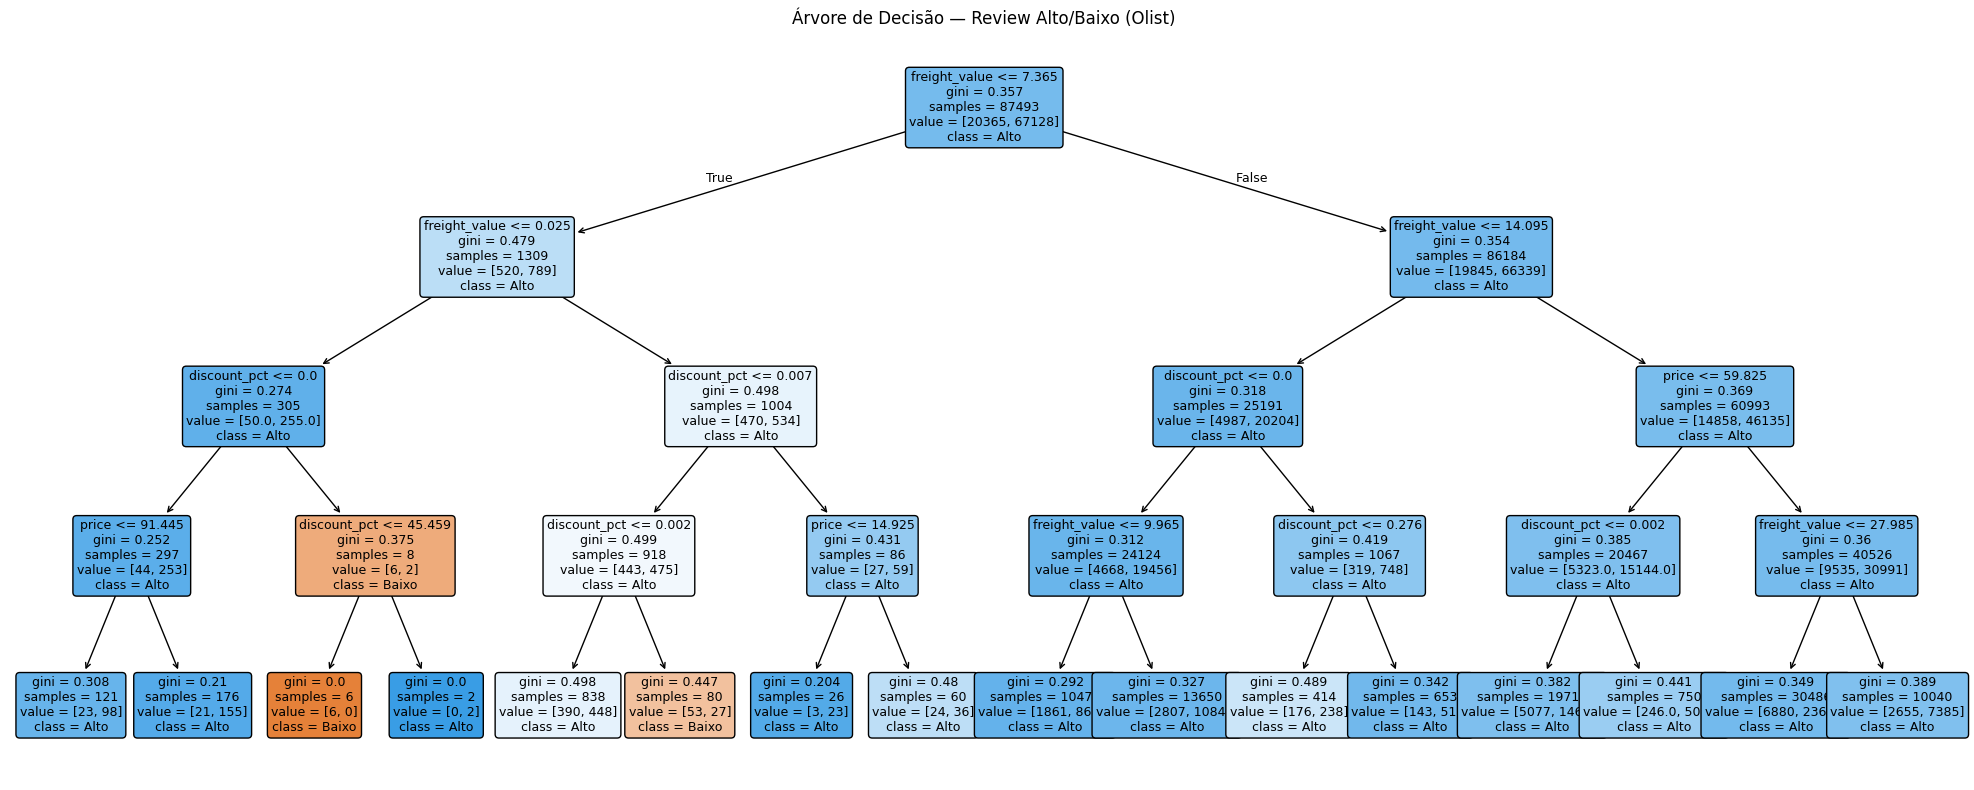

In [ ]:
df_tree = base_delivered[['price', 'freight_value', 'discount_pct', 'review_score']].dropna().copy()
df_tree['review_alto'] = (df_tree['review_score'] >= 4).astype(int)

X_tree = df_tree[['price', 'freight_value', 'discount_pct']]
y_tree = df_tree['review_alto']

X_train, X_test, y_train, y_test = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore.fit(X_train, y_train)
y_pred_tree = arvore.predict(X_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred_tree):.4f}")
print(classification_report(y_test, y_pred_tree, target_names=['Review Baixo', 'Review Alto']))

# Visualizar a árvore
plt.figure(figsize=(20, 8))
plot_tree(arvore, feature_names=['price', 'freight_value', 'discount_pct'],
          class_names=['Baixo', 'Alto'], filled=True, rounded=True, fontsize=9)
plt.title("Árvore de Decisão — Review Alto/Baixo (Olist)")
plt.tight_layout()
plt.show()

         receita_media  pedidos_medios  rating_medio  n_vendedores
cluster                                                           
0              3695.13           28.74          4.38          2535
1              1170.45            7.75          2.51           351
2            126168.67          952.22          4.07            23
3              9549.97            5.77          3.99            56


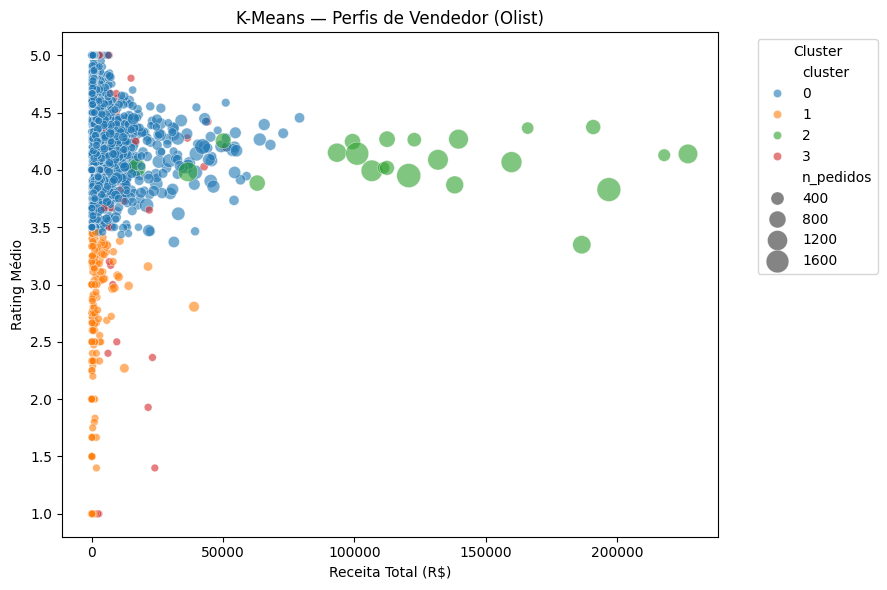

In [ ]:
# Agregar métricas por vendedor
df_sellers_agg = (base_delivered
    .groupby('seller_id')
    .agg(
        receita_total=('price', 'sum'),
        n_pedidos=('order_id', 'nunique'),
        rating_medio=('review_score', 'mean'),
        preco_medio=('price', 'mean'),
        desconto_medio=('discount_pct', 'mean')
    )
    .dropna()
    .reset_index()
)

X_sell = StandardScaler().fit_transform(
    df_sellers_agg[['receita_total', 'n_pedidos', 'rating_medio', 'preco_medio']]
)

km_sell = KMeans(n_clusters=4, random_state=42, n_init=10)
df_sellers_agg['cluster'] = km_sell.fit_predict(X_sell)

print(df_sellers_agg.groupby('cluster').agg(
    receita_media=('receita_total', 'mean'),
    pedidos_medios=('n_pedidos', 'mean'),
    rating_medio=('rating_medio', 'mean'),
    n_vendedores=('seller_id', 'count')
).round(2))

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_sellers_agg, x='receita_total', y='rating_medio',
                hue='cluster', size='n_pedidos', palette='tab10',
                alpha=0.6, sizes=(30, 300))
plt.title("K-Means — Perfis de Vendedor (Olist)")
plt.xlabel("Receita Total (R$)")
plt.ylabel("Rating Médio")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

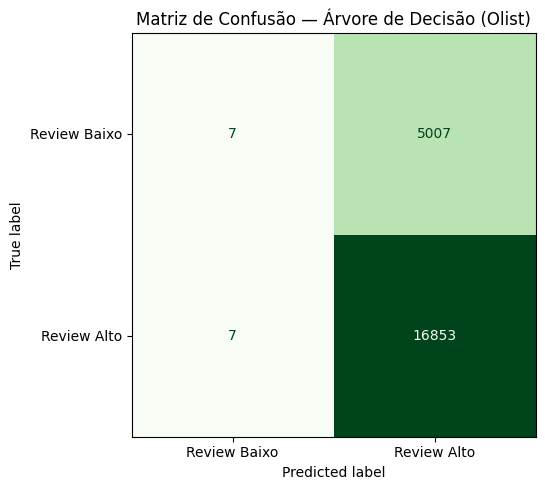

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree,
                                    display_labels=['Review Baixo', 'Review Alto'])
fig, ax = plt.subplots(figsize=(6, 5))
disp_tree.plot(ax=ax, colorbar=False, cmap='Greens')
plt.title("Matriz de Confusão — Árvore de Decisão (Olist)")
plt.tight_layout()
plt.show()